# 04 — County Risk Mapping & IRA Validation
### 2023/24 Kenya Housing Survey · MSc Dissertation
**Strathmore University · Data Science & Analytics**

## What this notebook does

| Phase | Purpose | Output |
|---|---|---|
| County aggregation | Aggregate household HFVS to county level | `county_risk_profile.csv` |
| Choropleth mapping | Spatial visualisation of vulnerability | `county_hfvs_choropleth.png` |
| Dimension decomposition | Per-county dimension contribution breakdown | `county_dimension_heatmap.png` |
| IRA validation | Correlate HFVS with IRA 2025 loss ratios | `ira_validation_results.csv` |
| OLS regression | Formal statistical validation model | `ols_validation_summary.txt` |
| Prediction residuals | Spatial model error analysis | `county_residuals_map.png` |

**Inputs:**
- `master_hfvs_v2.parquet` — full household dataset with HFVS scores
- `oof_predictions_v2.parquet` — out-of-fold predictions from notebook 03v2
- Kenya county shapefile (KNBS GitHub)
- IRA Insurance Annual Report 2025 — county-level loss ratios

**Dissertation relevance:**  
This is Chapter 5 — the external validation chapter. The core argument:
counties with high HFVS (modelled from household characteristics alone, no insurance variable)
should exhibit higher insurance loss ratios. A significant correlation is the actuarial validation
of the entire HFVS construction methodology.

---

## 1. Environment Setup

In [53]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys
os.chdir('/content')
!git clone https://github.com/VAL-Jerono/KHS_housing_dissertation.git 2>/dev/null || \
    (cd KHS_housing_dissertation && git pull)
os.chdir('KHS_housing_dissertation')
sys.path.insert(0, 'src')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already up to date.


In [54]:
!pip install -q polars pyarrow geopandas matplotlib seaborn scipy statsmodels mapclassify contextily

In [55]:
import json, warnings
import numpy as np
import pandas as pd
import polars as pl
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from pathlib import Path
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────
DRIVE  = Path('/content/drive/MyDrive/KHS_Dissertation')
PQ     = DRIVE / 'data' / 'parquet'
RAW    = DRIVE / 'data' / 'raw'
OUT    = DRIVE / 'outputs'
FIGS   = OUT / 'figures' / 'v2'
TABS   = OUT / 'tables'  / 'v2'
SHPS   = DRIVE / 'data'  / 'shapefiles'   # Kenya county shapefile location
for p in [FIGS, TABS, SHPS]: p.mkdir(parents=True, exist_ok=True)

# ── Publication plot style ─────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'        : 150,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#FAFAF8',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : '500',
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'font.family'       : 'sans-serif',
    'legend.framealpha' : 0.92,
    'legend.fontsize'   : 9,
})

TEAL   = '#1D9E75'
RED    = '#D85A30'
BLUE   = '#378ADD'
AMBER  = '#BA7517'
GRAY   = '#888780'
PURPLE = '#7F77DD'
DARK   = '#2C2C2A'

# ── All 47 Kenya counties (a01 code → name) ────────────────────────────
COUNTY_MAP = {
     1: 'Mombasa',        2: 'Kwale',           3: 'Kilifi',
     4: 'Tana River',     5: 'Lamu',            6: 'Taita-Taveta',
     7: 'Garissa',        8: 'Wajir',           9: 'Mandera',
    10: 'Marsabit',       11: 'Isiolo',         12: 'Meru',
    13: 'Tharaka-Nithi',  14: 'Embu',           15: 'Kitui',
    16: 'Machakos',       17: 'Makueni',        18: 'Nyandarua',
    19: 'Nyeri',          20: 'Kirinyaga',      21: "Murang'a",
    22: 'Kiambu',         23: 'Turkana',        24: 'West Pokot',
    25: 'Samburu',        26: 'Trans Nzoia',    27: 'Uasin Gishu',
    28: 'Elgeyo-Marakwet',29: 'Nandi',          30: 'Baringo',
    31: 'Laikipia',       32: 'Nakuru',         33: 'Narok',
    34: 'Kajiado',        35: 'Kericho',        36: 'Bomet',
    37: 'Kakamega',       38: 'Vihiga',         39: 'Bungoma',
    40: 'Busia',          41: 'Siaya',          42: 'Kisumu',
    43: 'Homa Bay',       44: 'Migori',         45: 'Kisii',
    46: 'Nyamira',        47: 'Nairobi'
}
INV_COUNTY_MAP = {v: k for k, v in COUNTY_MAP.items()}

print("Environment ready.")
print(f"  County map loaded: {len(COUNTY_MAP)} counties")

Environment ready.
  County map loaded: 47 counties


---
## 2. Load Data

In [56]:
# ── Master HFVS dataset (from notebook 02v2) ──────────────────────────
master = pl.read_parquet(PQ / 'master_hfvs_v2.parquet').to_pandas()
print(f"Master: {master.shape[0]:,} rows × {master.shape[1]} cols")

# ── OOF predictions (from notebook 03v2) ─────────────────────────────
oof = pl.read_parquet(PQ / 'oof_predictions_v2.parquet').to_pandas()
print(f"OOF:    {oof.shape[0]:,} rows × {oof.shape[1]} cols")
print(f"  OOF columns: {list(oof.columns)}")

# ── Merge OOF predictions back into master for county residual analysis
master_full = master.merge(
    oof[['interview__key', 'pred_xgb_cont', 'pred_xgb_bin',
         'pred_lgb_cont', 'pred_tabnet', 'pred_mlp']],
    on='interview__key', how='left'
)

# ── Attach county names ────────────────────────────────────────────────
master_full['county_name'] = master_full['a01'].map(COUNTY_MAP)
master_full['residence']   = master_full['a07_1'].map({1: 'Rural', 2: 'Urban'})

print(f"\nMaster with OOF: {master_full.shape}")
print(f"  Households with XGBoost predictions: {master_full['pred_xgb_cont'].notna().sum():,}")
print(f"  Counties represented: {master_full['county_name'].nunique()}")

Master: 21,347 rows × 128 cols
OOF:    21,347 rows × 13 cols
  OOF columns: ['interview__key', 'county_code', 'county_name', 'hhweight', 'hfvs_actual', 'target_binary', 'pred_xgb_cont', 'pred_xgb_bin', 'pred_lgb_cont', 'pred_lgb_bin', 'pred_tabnet', 'pred_mlp', 'pred_logistic']

Master with OOF: (21347, 134)
  Households with XGBoost predictions: 21,347
  Counties represented: 47


---
## 3. County-Level Aggregation

Aggregate household-level HFVS and all sub-scores to county level.
Survey weights (`hhweight`) are used for the primary weighted aggregates.
Unweighted counts are retained for sample-size transparency.

In [57]:
def weighted_mean(values, weights):
    """Weighted mean, ignoring NaN in values."""
    mask = ~np.isnan(values)
    if mask.sum() == 0:
        return np.nan
    return np.average(values[mask], weights=weights[mask])

def weighted_quantile(values, weights, q):
    """Weighted quantile."""
    mask = ~np.isnan(values)
    if mask.sum() == 0:
        return np.nan
    v, w = values[mask], weights[mask]
    sorter = np.argsort(v)
    v, w = v[sorter], w[sorter]
    cumw = np.cumsum(w)
    cutoff = cumw[-1] * q
    return v[np.searchsorted(cumw, cutoff)]

rows = []
for code, name in COUNTY_MAP.items():
    sub = master_full[master_full['a01'] == code].copy()
    if len(sub) == 0:
        continue
    w = sub['hhweight'].values

    # HFVS
    hfvs        = sub['hfvs'].values.astype(float)
    hfvs_high   = sub['target_binary'].values.astype(float)

    # Dimension sub-scores
    d1 = sub['d1_financial_stress'].values.astype(float)
    d2 = sub['d2_tenure_insecurity'].values.astype(float)
    d3 = sub['d3_physical_hazard'].values.astype(float)
    d4 = sub['d4_dwelling_quality'].values.astype(float)
    d5 = sub['d5_utility_deprivation'].values.astype(float)

    # Component flags
    rent_stressed  = sub['rent_stressed'].values.astype(float)
    no_land        = sub['no_land_ownership'].values.astype(float)
    eviction       = sub['eviction_threat'].values.astype(float)
    flood          = sub['flood_zone'].values.astype(float)
    no_elec        = sub['no_electricity'].values.astype(float)
    solid_fuel_col = sub['solid_fuel'].values.astype(float)
    unsafe_water_col = sub['unsafe_water'].values.astype(float)

    # Predictions
    pred_xgb  = sub['pred_xgb_cont'].values.astype(float)
    pred_lgb  = sub['pred_lgb_cont'].values.astype(float)

    row = {
        'county_code'           : code,
        'county_name'           : name,
        'n_households'          : len(sub),
        'total_weight'          : w.sum(),

        # HFVS — weighted
        'mean_hfvs'             : weighted_mean(hfvs, w),
        'p25_hfvs'              : weighted_quantile(hfvs, w, 0.25),
        'p75_hfvs'              : weighted_quantile(hfvs, w, 0.75),
        'pct_high_vuln'         : weighted_mean(hfvs_high, w),

        # Dimension means — weighted
        'mean_d1_financial'     : weighted_mean(d1, w),
        'mean_d2_tenure'        : weighted_mean(d2, w),
        'mean_d3_hazard'        : weighted_mean(d3, w),
        'mean_d4_dwelling'      : weighted_mean(d4, w),
        'mean_d5_utility'       : weighted_mean(d5, w),

        # Component flags — weighted prevalence
        'pct_rent_stressed'     : weighted_mean(rent_stressed, w),
        'pct_no_land'           : weighted_mean(no_land, w),
        'pct_eviction_threat'   : weighted_mean(eviction, w),
        'pct_flood_zone'        : weighted_mean(flood, w),
        'pct_no_electricity'    : weighted_mean(no_elec, w),
        'pct_solid_fuel'        : weighted_mean(solid_fuel_col, w),
        'pct_unsafe_water'      : weighted_mean(unsafe_water_col, w),

        # Geography
        'pct_urban'             : (sub['a07_1'] == 2).mean(),

        # Model predictions at county level (unweighted mean for residual analysis)
        'mean_pred_xgb'         : np.nanmean(pred_xgb),
        'mean_pred_lgb'         : np.nanmean(pred_lgb),
        'residual_xgb'          : np.nanmean(hfvs - pred_xgb),
        'abs_residual_xgb'      : np.nanmean(np.abs(hfvs - pred_xgb)),

        # Income proxy: median log expenditure
        'median_log_expenditure': np.nanmedian(sub['log_expenditure'].values.astype(float)),
    }
    rows.append(row)

county_risk = pd.DataFrame(rows).sort_values('mean_hfvs', ascending=False).reset_index(drop=True)
county_risk['hfvs_rank'] = county_risk['mean_hfvs'].rank(ascending=False).astype(int)

county_risk.to_csv(TABS / 'county_risk_profile.csv', index=False)

print(f"County risk profile: {county_risk.shape}")
print(f"\nTop 15 most vulnerable counties:")
display_cols = ['county_name', 'mean_hfvs', 'pct_high_vuln', 'mean_d1_financial',
                'mean_d2_tenure', 'mean_d3_hazard', 'pct_urban', 'n_households']
print(county_risk[display_cols].head(15).to_string(index=False, float_format=lambda x: f'{x:.3f}'))

County risk profile: (47, 27)

Top 15 most vulnerable counties:
    county_name  mean_hfvs  pct_high_vuln  mean_d1_financial  mean_d2_tenure  mean_d3_hazard  pct_urban  n_households
     Tana River      0.403          0.740              0.390           0.231           0.389      0.467           450
    Trans Nzoia      0.395          0.676              0.493           0.272           0.337      0.391           373
     West Pokot      0.390          0.772              0.486           0.151           0.113      0.381           517
        Samburu      0.390          0.751              0.480           0.222           0.166      0.408           478
        Mandera      0.355          0.571              0.428           0.226           0.113      0.535           503
        Turkana      0.355          0.631              0.398           0.107           0.095      0.440           368
Elgeyo-Marakwet      0.354          0.545              0.489           0.162           0.179      0.322       

In [58]:
# ── National benchmark statistics ─────────────────────────────────────
national_mean_hfvs    = county_risk['mean_hfvs'].mean()
national_median_hfvs  = county_risk['mean_hfvs'].median()
national_std          = county_risk['mean_hfvs'].std()

print("National HFVS statistics (county-level):")
print(f"  Mean county HFVS  : {national_mean_hfvs:.4f}")
print(f"  Median county HFVS: {national_median_hfvs:.4f}")
print(f"  Std dev           : {national_std:.4f}")
print(f"  Range             : {county_risk['mean_hfvs'].min():.4f} – {county_risk['mean_hfvs'].max():.4f}")
print(f"\nCounties above national mean: {(county_risk['mean_hfvs'] > national_mean_hfvs).sum()}")
print(f"Counties below national mean: {(county_risk['mean_hfvs'] <= national_mean_hfvs).sum()}")
print(f"\nBottom 10 least vulnerable:")
print(county_risk[display_cols].tail(10).to_string(index=False, float_format=lambda x: f'{x:.3f}'))

National HFVS statistics (county-level):
  Mean county HFVS  : 0.3236
  Median county HFVS: 0.3246
  Std dev           : 0.0313
  Range             : 0.2751 – 0.4027

Counties above national mean: 24
Counties below national mean: 23

Bottom 10 least vulnerable:
  county_name  mean_hfvs  pct_high_vuln  mean_d1_financial  mean_d2_tenure  mean_d3_hazard  pct_urban  n_households
 Taita-Taveta      0.293          0.257              0.497           0.111           0.197      0.407           405
     Laikipia      0.291          0.259              0.448           0.185           0.125      0.434           445
     Machakos      0.291          0.245              0.501           0.244           0.093      0.426           618
         Embu      0.290          0.290              0.468           0.123           0.182      0.377           406
       Nakuru      0.290          0.260              0.420           0.209           0.163      0.484           686
Tharaka-Nithi      0.288          0.244   

---
## 4. Download Kenya County Shapefile

The official Kenya county boundary shapefile from KNBS GitHub.
If already downloaded, the cell skips the download.

In [59]:
# ── Download Kenya county shapefile ───────────────────────────────────
# Primary source: KNBS GitHub (official Kenya county boundaries)
# Fallback: geoBoundaries Kenya ADM1

# ── Download Kenya county shapefile ───────────────────────────────────
import requests, zipfile, io, shutil

# Clear stale files
if SHPS.exists():
    shutil.rmtree(SHPS)
SHPS.mkdir(parents=True, exist_ok=True)

shp_path = None

# ── Strategy 1: geoBoundaries API (resolves current URL dynamically) ──
try:
    print("Querying geoBoundaries API for current KEN ADM1 URL...")
    api = requests.get(
        "https://www.geoboundaries.org/api/current/gbOpen/KEN/ADM1/",
        timeout=30
    )
    api.raise_for_status()
    dl_url = api.json()['gjDownloadURL']   # GeoJSON — no zip needed
    print(f"Fetching: {dl_url}")
    r = requests.get(dl_url, timeout=60)
    r.raise_for_status()
    geojson_path = SHPS / 'kenya_adm1.geojson'
    geojson_path.write_bytes(r.content)
    shp_path = geojson_path
    print("✓ Downloaded via geoBoundaries API")
except Exception as e:
    print(f"✗ API strategy failed: {e}")

# ── Strategy 2: HDX direct GeoJSON (stable CDN) ───────────────────────
if shp_path is None:
    try:
        url = "https://data.humdata.org/dataset/geoboundaries-admin-boundaries-for-kenya/resource/f31d70c1-1257-482b-8932-3209578aff45/download/geoBoundaries-KEN-ADM1.geojson"
        print(f"Trying HDX: {url}")
        r = requests.get(url, timeout=60)
        r.raise_for_status()
        geojson_path = SHPS / 'kenya_adm1.geojson'
        geojson_path.write_bytes(r.content)
        shp_path = geojson_path
        print("✓ Downloaded from HDX")
    except Exception as e:
        print(f"✗ HDX failed: {e}")

# ── Strategy 3: pinned geoBoundaries commit (from HDX metadata) ───────
if shp_path is None:
    try:
        url = "https://github.com/wmgeolab/geoBoundaries/raw/905b0ba/releaseData/gbOpen/KEN/ADM1/geoBoundaries-KEN-ADM1.geojson"
        print(f"Trying pinned commit: {url}")
        r = requests.get(url, timeout=60)
        r.raise_for_status()
        geojson_path = SHPS / 'kenya_adm1.geojson'
        geojson_path.write_bytes(r.content)
        shp_path = geojson_path
        print("✓ Downloaded from pinned commit")
    except Exception as e:
        print(f"✗ Pinned commit failed: {e}")

if shp_path is None:
    print("\nMANUAL STEP REQUIRED:")
    print("  1. Go to: https://www.geoboundaries.org/countryDownloads.html")
    print("  2. Search Kenya → ADM1 → download GeoJSON")
    print(f"  3. Upload to: {SHPS}/kenya_adm1.geojson")
else:
    kenya_gdf = gpd.read_file(shp_path)
    kenya_gdf = kenya_gdf.to_crs('EPSG:4326')
    print(f"\nShape: {kenya_gdf.shape}  ← expect (47, N)")
    print(f"Columns: {kenya_gdf.columns.tolist()}")
    print(f"Sample names: {sorted(kenya_gdf['shapeName'].tolist())[:5]}")


Querying geoBoundaries API for current KEN ADM1 URL...
Fetching: https://github.com/wmgeolab/geoBoundaries/raw/9469f09/releaseData/gbOpen/KEN/ADM1/geoBoundaries-KEN-ADM1.geojson
✓ Downloaded via geoBoundaries API

Shape: (47, 6)  ← expect (47, N)
Columns: ['shapeName', 'shapeISO', 'shapeID', 'shapeGroup', 'shapeType', 'geometry']
Sample names: ['Baringo', 'Bomet', 'Bungoma', 'Busia', 'Elgeyo-Marakwet']


In [60]:
# ── Load shapefile and inspect ─────────────────────────────────────────
shp_path = SHPS / 'kenya_adm1.geojson'   # set directly — no glob needed

kenya_gdf = gpd.read_file(shp_path)
kenya_gdf = kenya_gdf.to_crs('EPSG:4326')

print(f"Shapefile loaded: {kenya_gdf.shape}")
print(f"CRS: {kenya_gdf.crs}")
print(f"\nColumns: {list(kenya_gdf.columns)}")
print(f"\nFirst 5 rows:")
print(kenya_gdf[kenya_gdf.columns[:5]].head())

# ── Identify the county name column ───────────────────────────────────
name_candidates = ['shapeName', 'COUNTY_NAM', 'County', 'NAME_1', 'county_name', 'COUNTY']
NAME_COL = next((c for c in name_candidates if c in kenya_gdf.columns), kenya_gdf.columns[0])
print(f"\nUsing county name column: '{NAME_COL}'")
print(f"Sample county names from shapefile:")
print(sorted(kenya_gdf[NAME_COL].tolist())[:10])

Shapefile loaded: (47, 6)
CRS: EPSG:4326

Columns: ['shapeName', 'shapeISO', 'shapeID', 'shapeGroup', 'shapeType', 'geometry']

First 5 rows:
    shapeName shapeISO                  shapeID shapeGroup shapeType
0     Turkana    KE-43  32016919B72266624462344        KEN      ADM1
1    Marsabit    KE-25  32016919B63496705134089        KEN      ADM1
2     Mandera    KE-24   32016919B2031803566233        KEN      ADM1
3       Wajir    KE-46  32016919B89873713911655        KEN      ADM1
4  West Pokot    KE-47  32016919B96045830258165        KEN      ADM1

Using county name column: 'shapeName'
Sample county names from shapefile:
['Baringo', 'Bomet', 'Bungoma', 'Busia', 'Elgeyo-Marakwet', 'Embu', 'Garissa', 'Homa Bay', 'Isiolo', 'Kajiado']


In [61]:
# ── Name harmonisation: shapefile → COUNTY_MAP names ──────────────────
# Shapefile names and survey names may differ in capitalisation, accents, or spelling.
# This cell builds the crosswalk.

# Normalise: uppercase, strip spaces
def normalise(s):
    return str(s).upper().strip().replace("'", "").replace("-", " ")

survey_names_norm = {normalise(v): v for v in COUNTY_MAP.values()}

# Build crosswalk
crosswalk = {}
unmatched = []
for shp_name in kenya_gdf[NAME_COL].tolist():
    norm = normalise(shp_name)
    if norm in survey_names_norm:
        crosswalk[shp_name] = survey_names_norm[norm]
    else:
        # Fuzzy fallback: check if any survey name is a substring
        matched = False
        for survey_norm, survey_name in survey_names_norm.items():
            if survey_norm in norm or norm in survey_norm:
                crosswalk[shp_name] = survey_name
                matched = True
                break
        if not matched:
            unmatched.append(shp_name)

print(f"Matched: {len(crosswalk)} counties")
if unmatched:
    print(f"Unmatched shapefile names (manual review needed): {unmatched}")
    print("\nAdd manual mappings below:")
    # ── MANUAL OVERRIDES (add as needed based on unmatched output) ────
    MANUAL_MAP = {
        # 'Shapefile Name': 'Survey Name',
        # e.g. 'Murang\'a': "Murang'a",
        # e.g. 'Homabay': 'Homa Bay',
        # e.g. 'Tharaka Nithi': 'Tharaka-Nithi',
        # e.g. 'Elgeyo/Marakwet': 'Elgeyo-Marakwet',
    }
    crosswalk.update(MANUAL_MAP)
    print(f"After manual overrides: {len(crosswalk)} matched")
else:
    print("All counties matched successfully.")




# Apply crosswalk to shapefile
kenya_gdf['county_name_std'] = kenya_gdf[NAME_COL].map(crosswalk)

# ── FIX: NaN from unmatched rows makes the column float64 ─────────────
# Cast back to string so the merge key dtypes match county_risk['county_name']
kenya_gdf['county_name_std'] = kenya_gdf['county_name_std'].astype(str)
# (unmatched rows become the string "nan" — visible in the match report below)

print(f"\nFinal match rate: {kenya_gdf['county_name_std'].notna().mean()*100:.1f}%")
print(f"county_name_std dtype: {kenya_gdf['county_name_std'].dtype}")   # should be object


Matched: 47 counties
All counties matched successfully.

Final match rate: 100.0%
county_name_std dtype: object


In [62]:
# ── Merge HFVS data into geodataframe ─────────────────────────────────
kenya_merged = kenya_gdf.merge(
    county_risk,
    left_on='county_name_std',
    right_on='county_name',
    how='left'
)

matched = kenya_merged['mean_hfvs'].notna().sum()
print(f"Shapefile rows: {len(kenya_merged)}")
print(f"Matched with HFVS data: {matched} counties")
if matched < 47:
    unmatched_counties = kenya_merged[kenya_merged['mean_hfvs'].isna()]['county_name_std'].tolist()
    print(f"Still unmatched: {unmatched_counties}")
    print("\nAction: add entries to MANUAL_MAP in the cell above and re-run.")

Shapefile rows: 47
Matched with HFVS data: 47 counties


In [63]:
unmatched_counties = kenya_merged[kenya_merged['mean_hfvs'].isna()]['county_name_std'].tolist()
print(f"Still unmatched: {unmatched_counties}")

Still unmatched: []


In [64]:
print(kenya_gdf.shape)
print(kenya_gdf.columns.tolist())
print(kenya_gdf[NAME_COL].tolist())

(47, 7)
['shapeName', 'shapeISO', 'shapeID', 'shapeGroup', 'shapeType', 'geometry', 'county_name_std']
['Turkana', 'Marsabit', 'Mandera', 'Wajir', 'West Pokot', 'Samburu', 'Isiolo', 'Baringo', 'Elgeyo-Marakwet', 'Trans Nzoia', 'Bungoma', 'Garissa', 'Uasin Gishu', 'Kakamega', 'Laikipia', 'Busia', 'Meru', 'Nandi', 'Siaya', 'Nakuru', 'Vihiga', 'Nyandarua', 'Tharaka', 'Kericho', 'Kisumu', 'Nyeri', 'Tana River', 'Kitui', 'Kirinyaga', 'Embu', 'Homa Bay', 'Bomet', 'Nyamira', 'Narok', 'Kisii', "Murang'a", 'Migori', 'Kiambu', 'Machakos', 'Kajiado', 'Nairobi', 'Makueni', 'Lamu', 'Kilifi', 'Taita Taveta', 'Kwale', 'Mombasa']


---
## 5. Choropleth Map — Housing Financial Vulnerability

Publication-quality county risk map for Chapter 5.

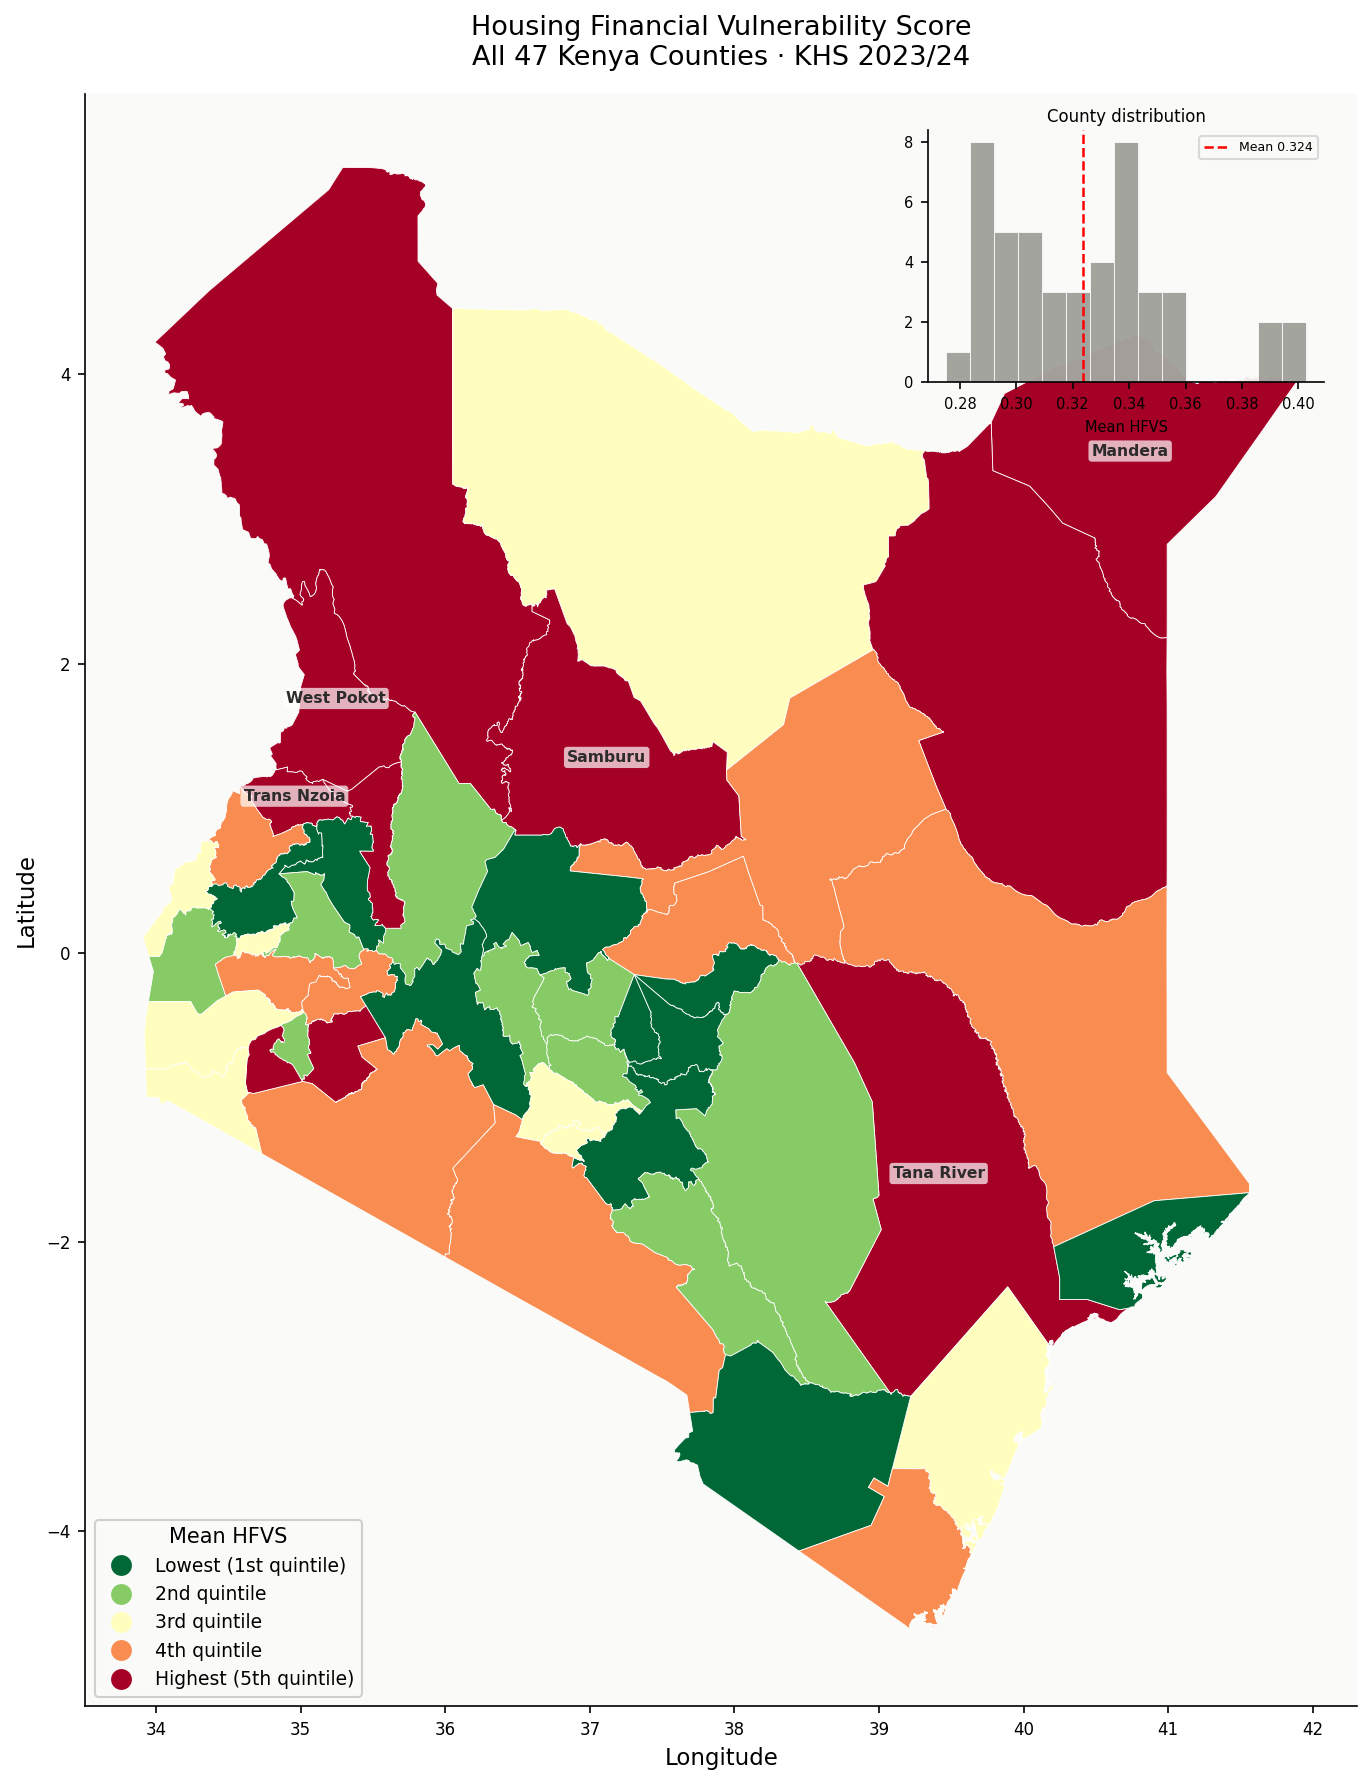

Choropleth saved.


In [84]:
from mapclassify import NaturalBreaks, Quantiles, FisherJenks

# ── 5.1 Single-panel choropleth ────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(11, 12))
ax.set_aspect('equal')

kenya_merged.plot(
    column      = 'mean_hfvs',
    cmap        = 'RdYlGn_r',
    scheme      = 'quantiles',
    k           = 5,
    linewidth   = 0.4,
    edgecolor   = 'white',
    legend      = True,
    legend_kwds = {
        'title'     : 'Mean HFVS',
        'loc'       : 'lower left',
        'fmt'       : '{:.3f}',
        'labels'    : ['Lowest (1st quintile)', '2nd quintile', '3rd quintile',
                       '4th quintile', 'Highest (5th quintile)'],
        'framealpha': 0.92,
    },
    ax          = ax,
    missing_kwds= {'color': '#DDDDDD', 'label': 'No data'},
)

# Annotate top 5 most vulnerable counties
top5 = county_risk.head(5)
for _, row in top5.iterrows():
    match = kenya_merged[kenya_merged['county_name'] == row['county_name']]
    if len(match) > 0:
        centroid = match.geometry.centroid.iloc[0]
        ax.annotate(
            row['county_name'],
            xy         = (centroid.x, centroid.y),
            fontsize   = 7.5,
            fontweight = '600',
            ha         = 'center',
            color      = '#2C2C2A',
            bbox       = dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, lw=0),
        )

ax.set_title(
    'Housing Financial Vulnerability Score\nAll 47 Kenya Counties · KHS 2023/24',
    fontsize=13, fontweight='500', pad=14
)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.tick_params(labelsize=8)

# ── Inset: top-right corner (empty space above northeast Kenya) ───────
plt.tight_layout()
fig.canvas.draw()

ax_pos = ax.get_position()
inset_w = 0.24
inset_h = 0.14
inset_x = ax_pos.x0 + ax_pos.width - inset_w - 0.02   # right-aligned with map
inset_y = ax_pos.y0 + ax_pos.height - inset_h - 0.02  # top of map, just inside

ax_in = fig.add_axes([inset_x, inset_y, inset_w, inset_h])
ax_in.hist(county_risk['mean_hfvs'], bins=15, color='#888780',
           alpha=0.75, edgecolor='white', linewidth=0.5)
ax_in.axvline(national_mean_hfvs, color='red', linewidth=1.2,
              linestyle='--', label=f'Mean {national_mean_hfvs:.3f}')
ax_in.legend(fontsize=6, framealpha=0.7)
ax_in.set_title('County distribution', fontsize=8, pad=4)
ax_in.tick_params(labelsize=7)
ax_in.set_xlabel('Mean HFVS', fontsize=7)
ax_in.set_facecolor('#FAFAF8')
ax_in.patch.set_alpha(0.92)
for sp in ['top', 'right']:
    ax_in.spines[sp].set_visible(False)


plt.savefig(FIGS / '05a_county_hfvs_choropleth.png', dpi=200, bbox_inches='tight')
plt.show()
print("Choropleth saved.")

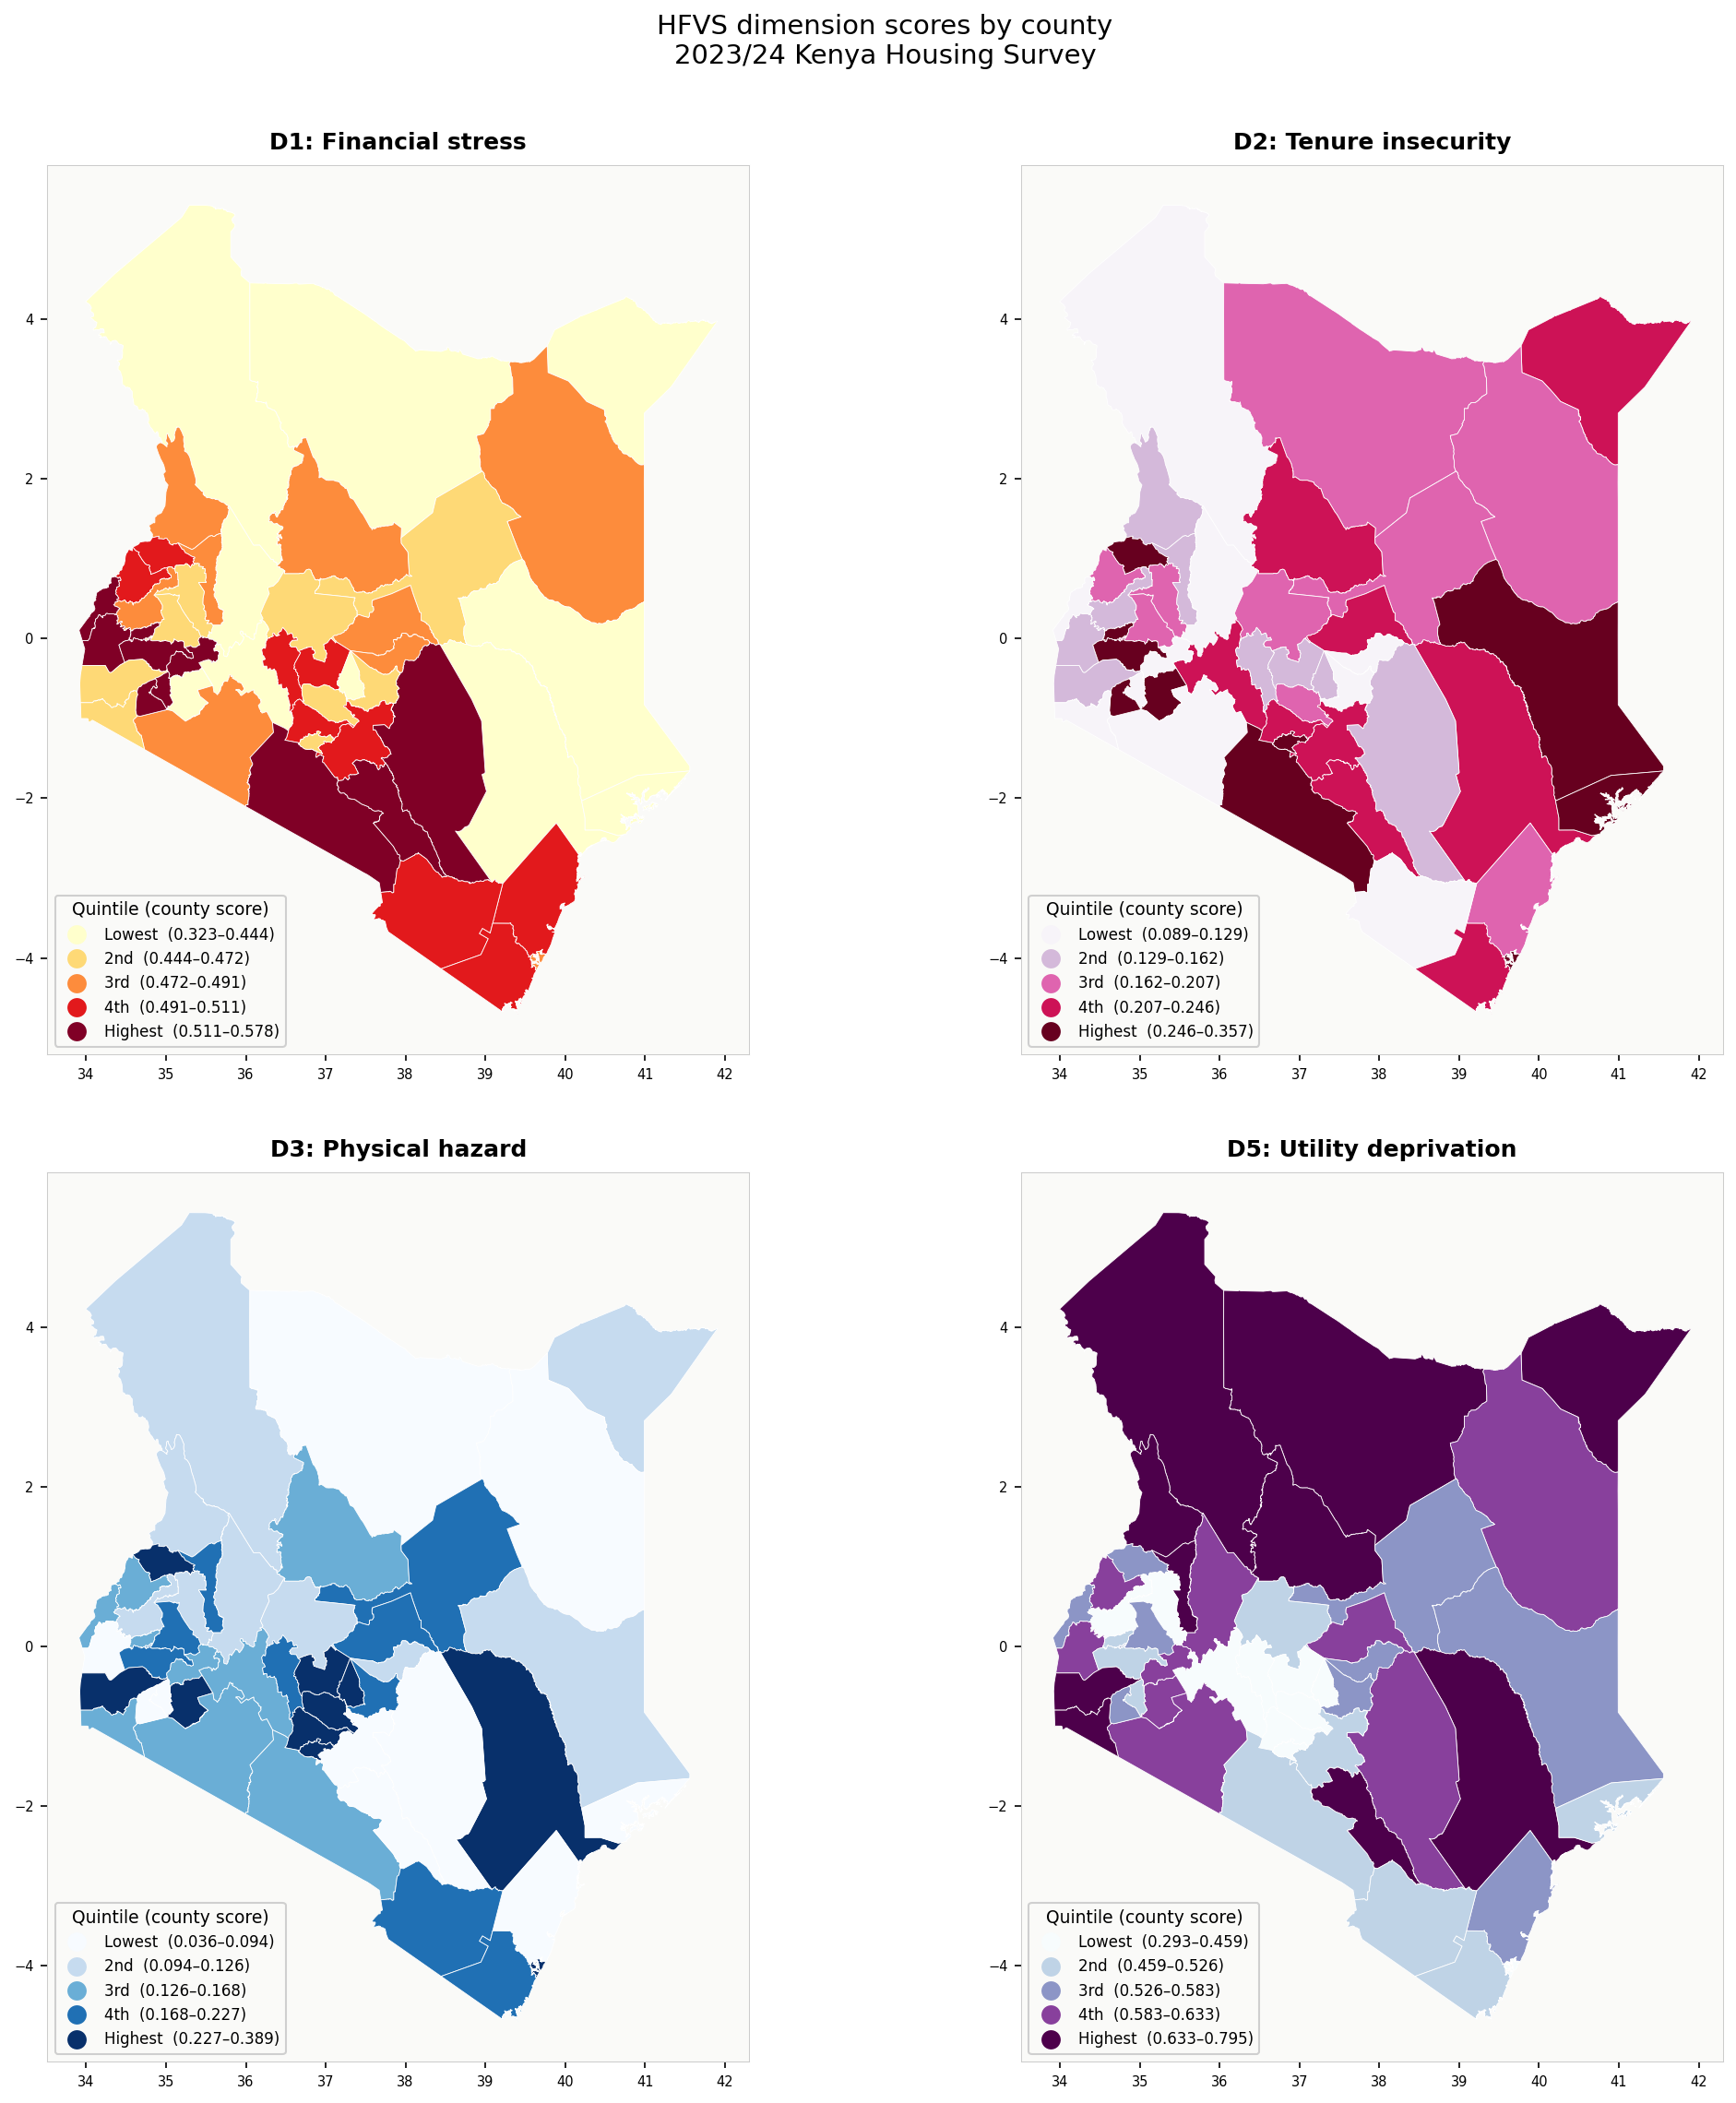

Dimension maps saved.


In [85]:
# ── 5.2 Four-panel dimension decomposition map ─────────────────────────
dim_cols = [
    ('mean_d1_financial', 'D1: Financial stress',    'YlOrRd'),
    ('mean_d2_tenure',    'D2: Tenure insecurity',   'PuRd'),
    ('mean_d3_hazard',    'D3: Physical hazard',     'Blues'),
    ('mean_d5_utility',   'D5: Utility deprivation', 'BuPu'),
]

quintile_labels = ['Lowest', '2nd', '3rd', '4th', 'Highest']

fig, axes = plt.subplots(2, 2, figsize=(15, 15))
fig.suptitle(
    'HFVS dimension scores by county\n2023/24 Kenya Housing Survey',
    fontsize=14, fontweight='500', y=1.01
)

for ax, (col, title, cmap) in zip(axes.flatten(), dim_cols):
    kenya_merged.plot(
        column       = col,
        cmap         = cmap,
        scheme       = 'quantiles',
        k            = 5,
        linewidth    = 0.4,
        edgecolor    = 'white',
        legend       = True,
        legend_kwds  = {
            'title'      : 'Quintile (county score)',
            'title_fontsize': 9,
            'fontsize'   : 8,
            'fmt'        : '{:.3f}',
            'framealpha' : 0.92,
            'loc'        : 'lower left',
            'labels'     : [
                f'{q}  ({kenya_merged[col].quantile(i*0.2):.3f}–{kenya_merged[col].quantile((i+1)*0.2):.3f})'
                for i, q in enumerate(quintile_labels)
            ],
        },
        ax           = ax,
        missing_kwds = {'color': '#DDDDDD', 'label': 'No data'},
    )
    ax.set_title(title, fontsize=12, fontweight='600', pad=8)
    ax.tick_params(labelsize=7)
    ax.set_aspect('equal')

    # Add a thin border around each panel
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color('#CCCCCC')

plt.tight_layout(h_pad=3, w_pad=2)
plt.savefig(FIGS / '05b_dimension_maps.png', dpi=180, bbox_inches='tight')
plt.show()
print("Dimension maps saved.")

---
## 6. County Risk Ranking — Full Table

Publication-quality ranked table for appendix and Chapter 5.

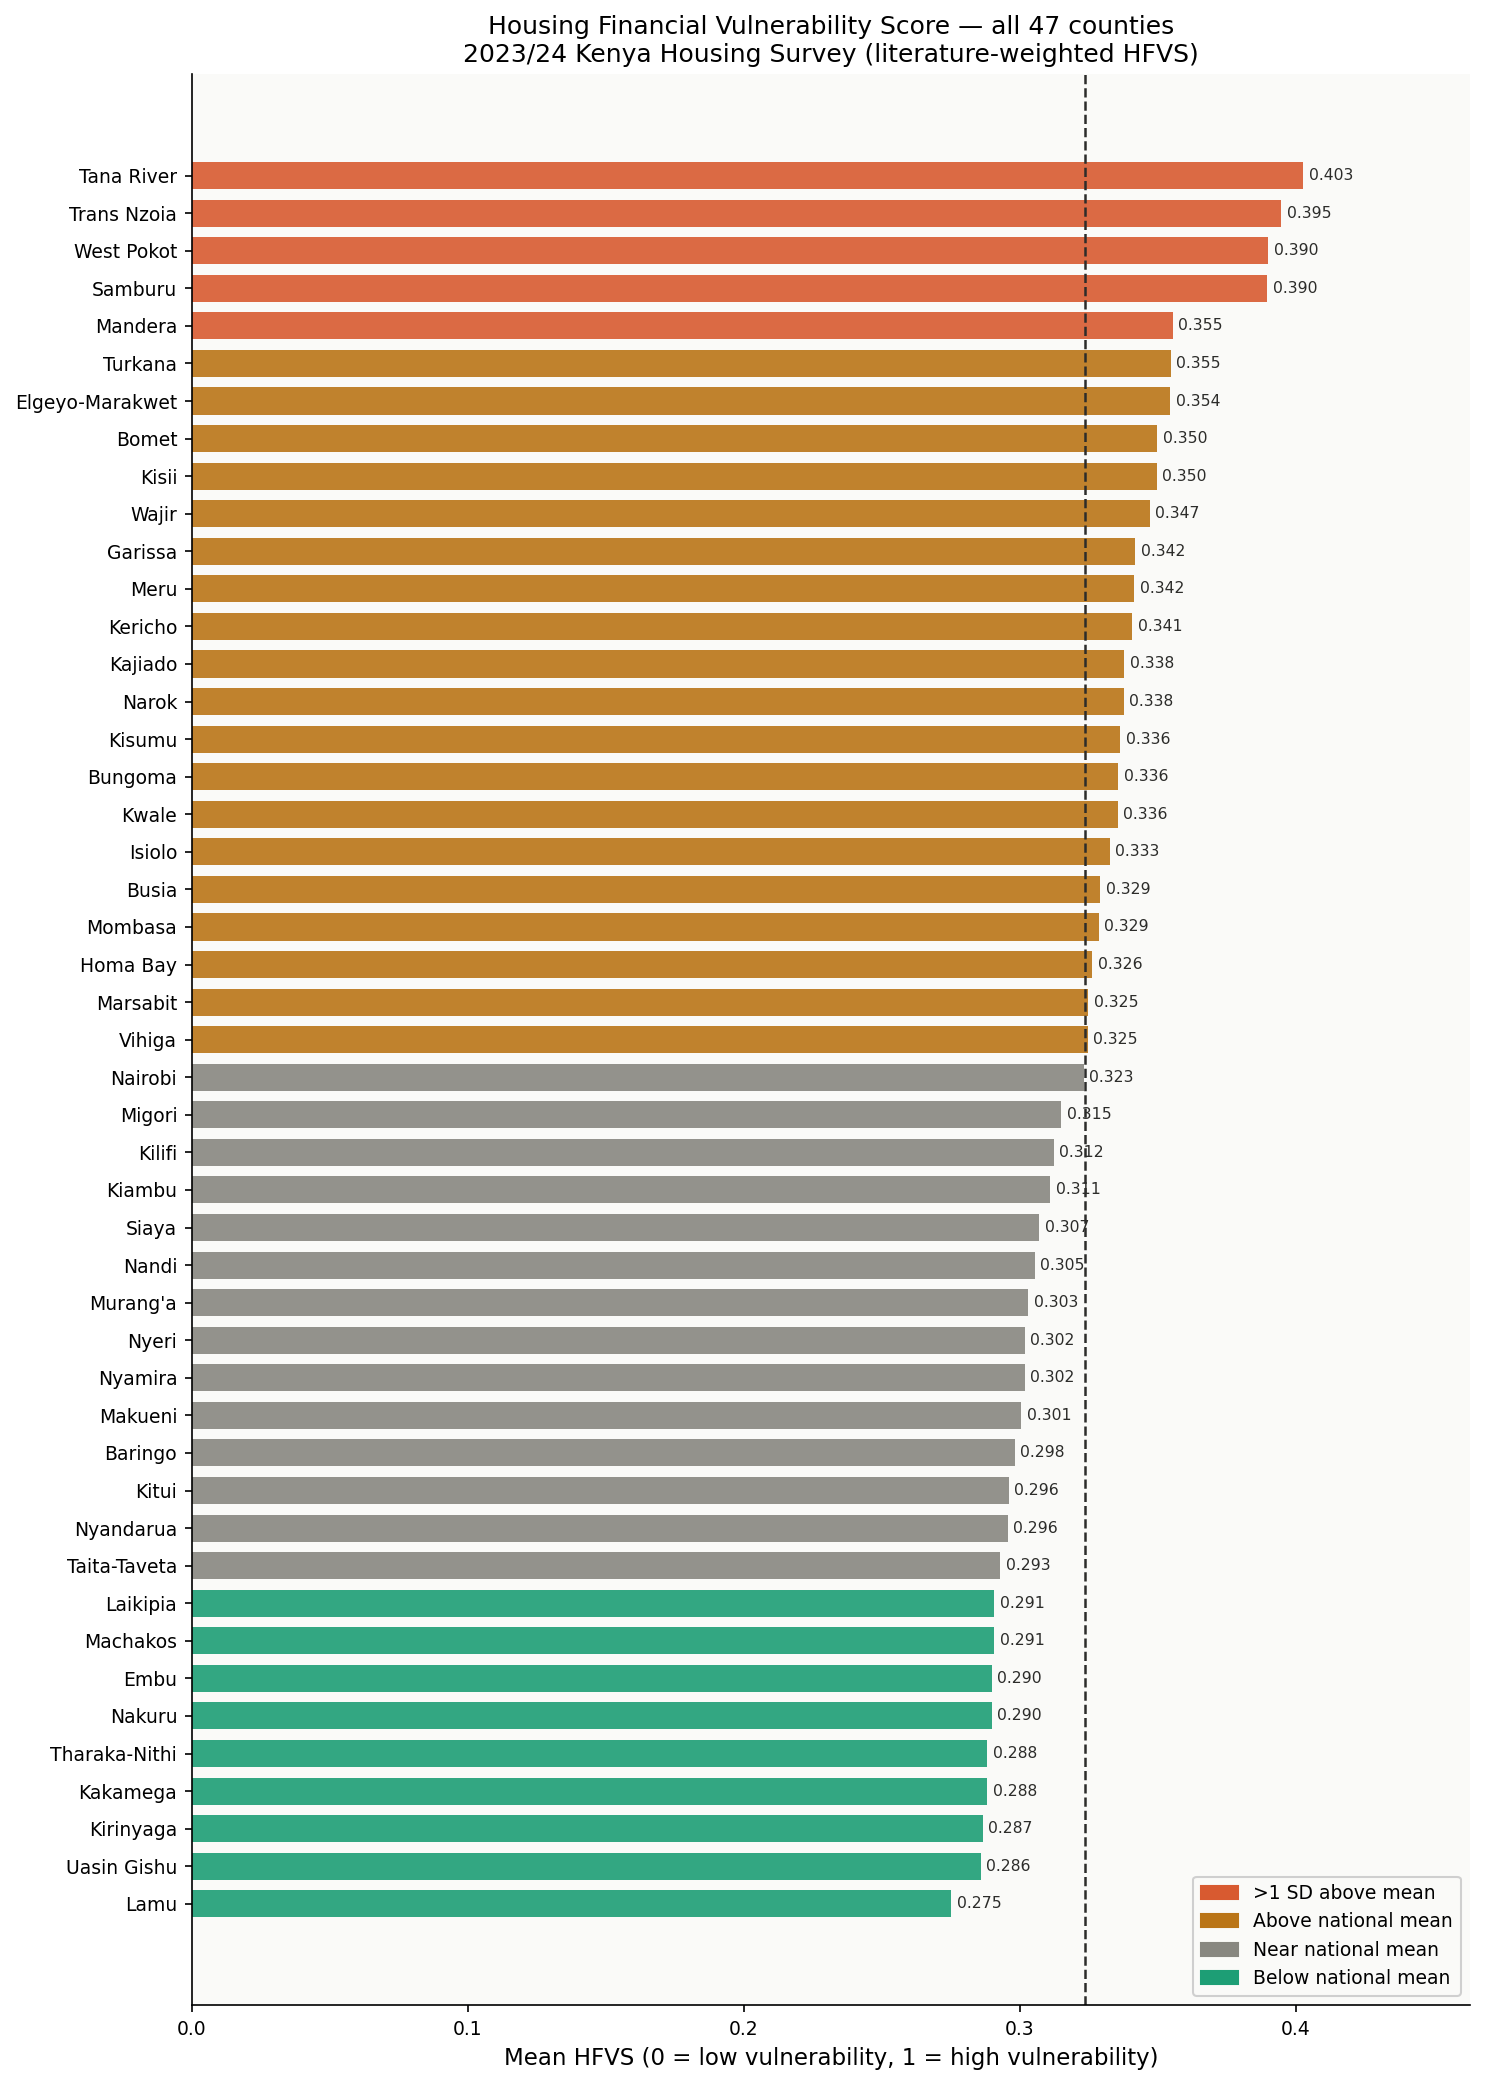

County ranking chart saved.


In [67]:
# ── Full 47-county ranked bar chart ───────────────────────────────────
c_sorted = county_risk.sort_values('mean_hfvs')

fig, ax = plt.subplots(figsize=(10, 14))

bar_colors = []
for v in c_sorted['mean_hfvs']:
    if v > national_mean_hfvs + national_std:
        bar_colors.append('#D85A30')   # high risk — coral
    elif v > national_mean_hfvs:
        bar_colors.append('#BA7517')   # above mean — amber
    elif v > national_mean_hfvs - national_std:
        bar_colors.append('#888780')   # near mean — gray
    else:
        bar_colors.append('#1D9E75')   # low risk — teal

bars = ax.barh(
    c_sorted['county_name'], c_sorted['mean_hfvs'],
    color=bar_colors, edgecolor='none', alpha=0.90, height=0.72
)

# National mean reference line
ax.axvline(national_mean_hfvs, color=DARK, linewidth=1.2, linestyle='--',
           label=f'National mean ({national_mean_hfvs:.3f})')

# Value labels
for bar, val in zip(bars, c_sorted['mean_hfvs']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=7.5, color=DARK)

# Legend patches
legend_elements = [
    mpatches.Patch(color='#D85A30', label=f'>1 SD above mean'),
    mpatches.Patch(color='#BA7517', label='Above national mean'),
    mpatches.Patch(color='#888780', label='Near national mean'),
    mpatches.Patch(color='#1D9E75', label='Below national mean'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

ax.set_xlabel('Mean HFVS (0 = low vulnerability, 1 = high vulnerability)', fontsize=11)
ax.set_title(
    'Housing Financial Vulnerability Score — all 47 counties\n'
    '2023/24 Kenya Housing Survey (literature-weighted HFVS)',
    fontsize=12, fontweight='500'
)
ax.tick_params(axis='y', labelsize=9)
ax.set_xlim(0, c_sorted['mean_hfvs'].max() * 1.15)

plt.tight_layout()
plt.savefig(FIGS / '05c_county_ranking.png', dpi=180, bbox_inches='tight')
plt.show()
print("County ranking chart saved.")

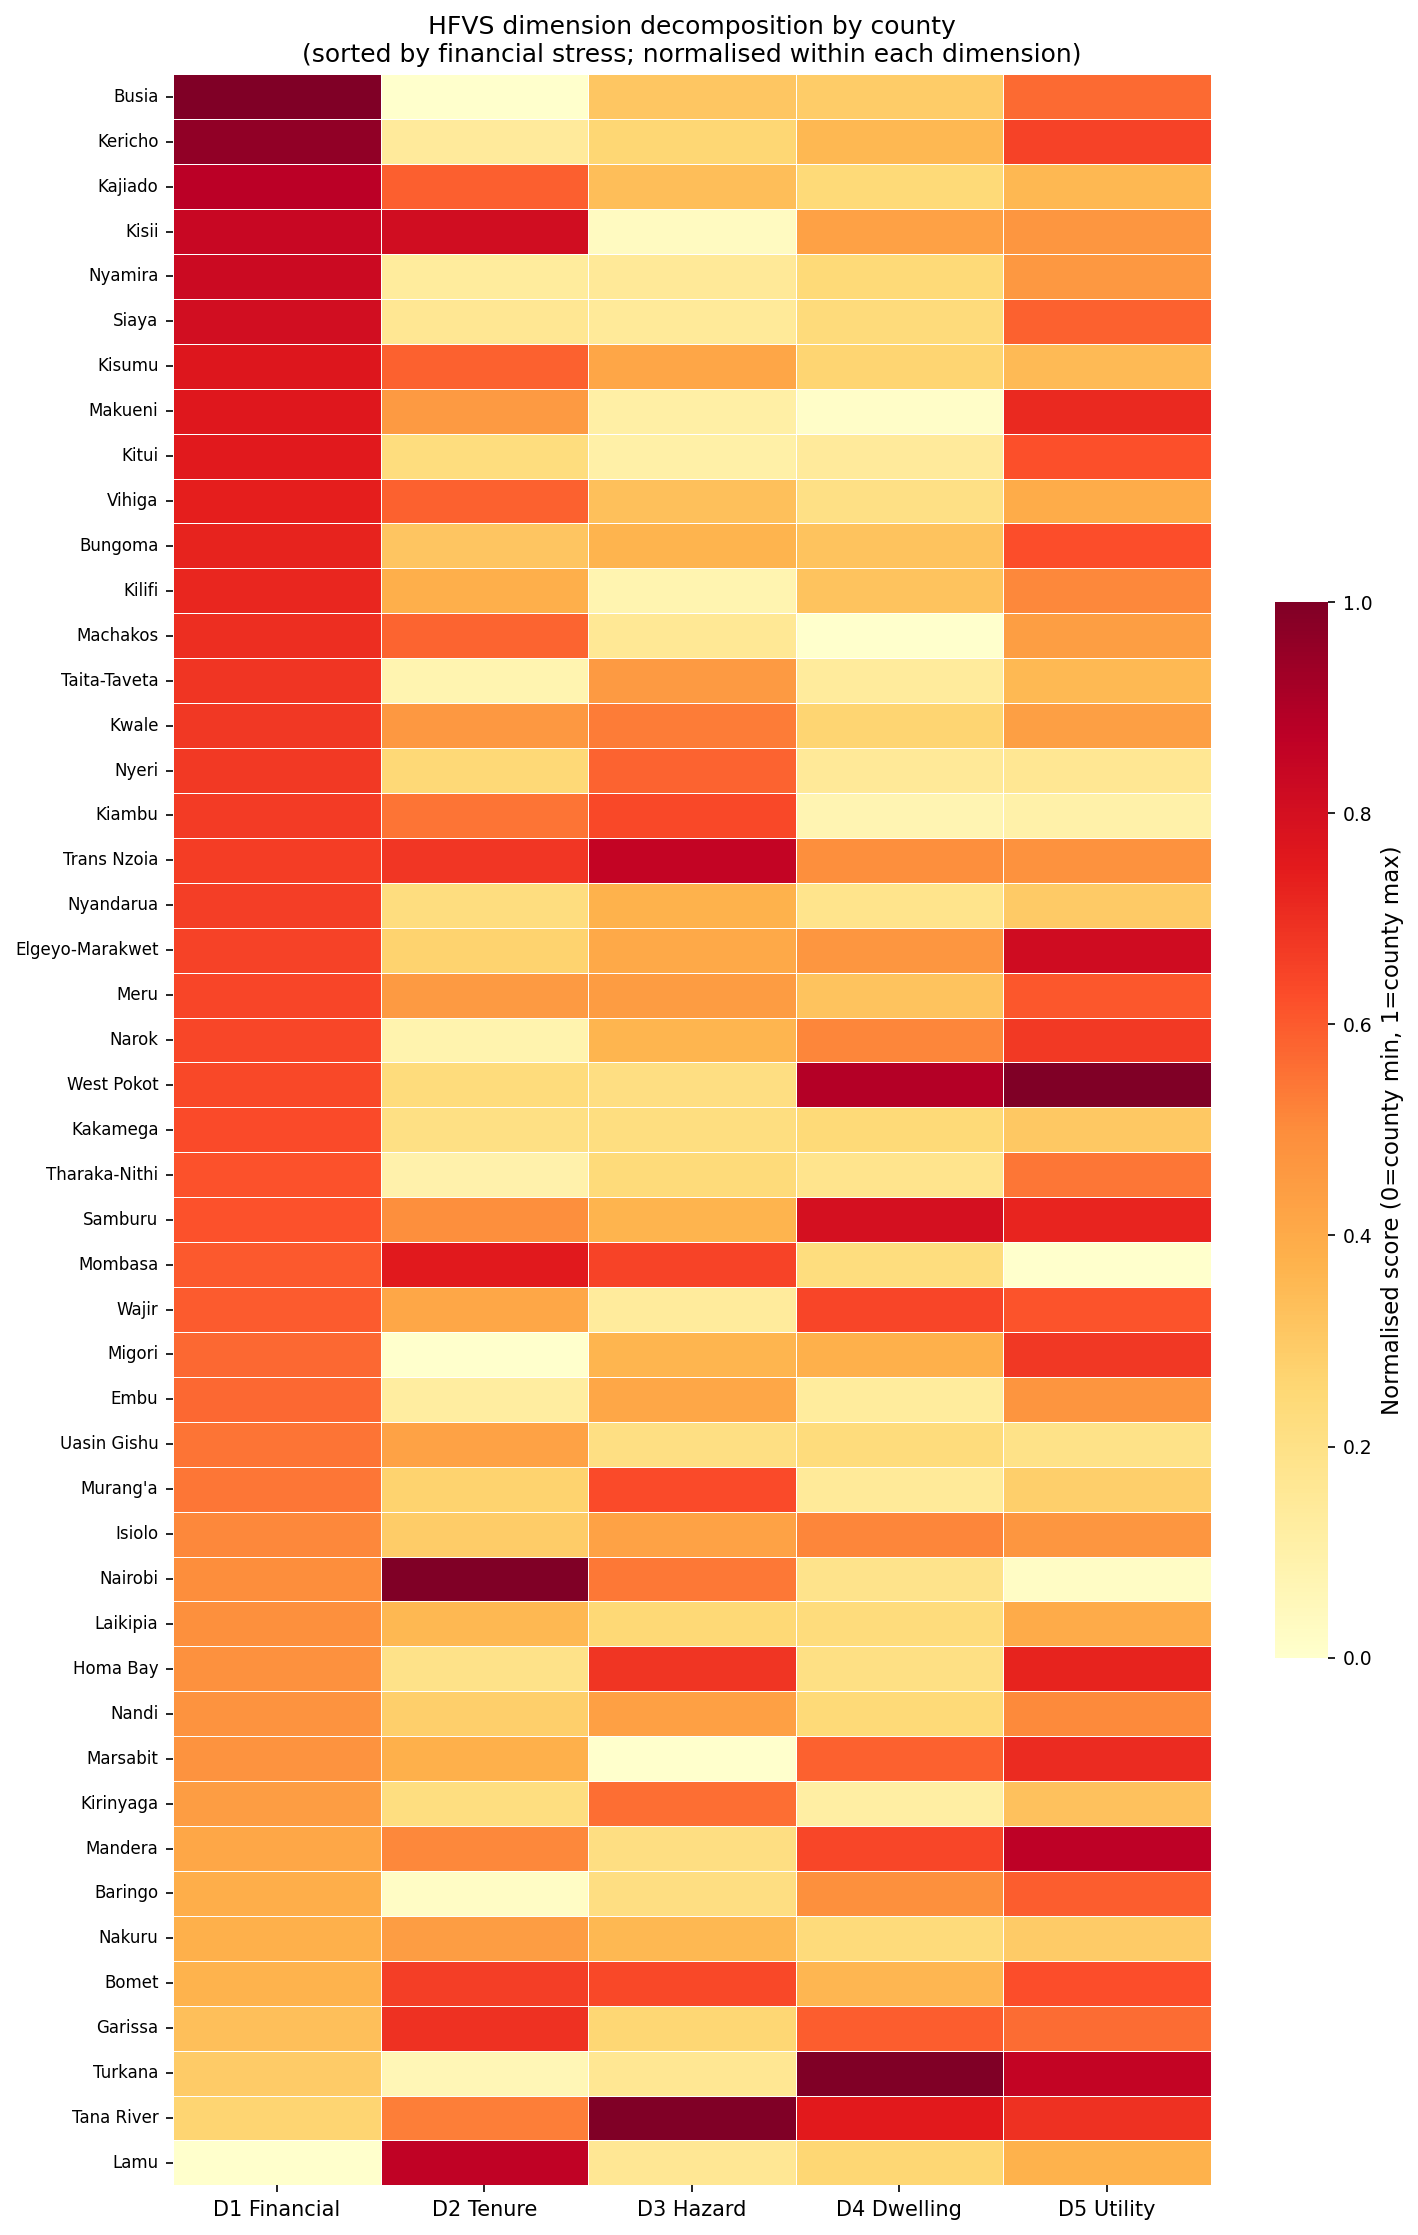

Dimension heatmap saved.


In [68]:
# ── Dimension contribution heatmap (all 47 counties × 5 dimensions) ────
dim_heat_cols = [
    'mean_d1_financial', 'mean_d2_tenure', 'mean_d3_hazard',
    'mean_d4_dwelling', 'mean_d5_utility'
]
dim_labels = ['D1 Financial', 'D2 Tenure', 'D3 Hazard', 'D4 Dwelling', 'D5 Utility']

heat_data = county_risk.set_index('county_name')[dim_heat_cols].copy()
heat_data.columns = dim_labels
# Normalise each dimension 0–1 for visual comparison
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min())

fig, ax = plt.subplots(figsize=(10, 15))
sns.heatmap(
    heat_norm.sort_values('D1 Financial', ascending=False),
    cmap        = 'YlOrRd',
    ax          = ax,
    linewidths  = 0.4,
    linecolor   = 'white',
    cbar_kws    = {'label': 'Normalised score (0=county min, 1=county max)', 'shrink': 0.5},
    annot       = False,
    vmin        = 0,
    vmax        = 1,
)
ax.set_title(
    'HFVS dimension decomposition by county\n'
    '(sorted by financial stress; normalised within each dimension)',
    fontsize=12, fontweight='500'
)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=8)
ax.tick_params(axis='x', labelsize=10)

plt.tight_layout()
plt.savefig(FIGS / '05d_dimension_heatmap.png', dpi=180, bbox_inches='tight')
plt.show()
print("Dimension heatmap saved.")

---
## 7. IRA Validation

### Setup: IRA 2025 loss ratio data

**Source:** Insurance Regulatory Authority, *Insurance Annual Report 2025*,
county-level loss ratios for residential property and household insurance lines.

**How to obtain:**
1. Download from https://www.ira.go.ke → Publications → Annual Reports
2. Extract the county-level loss ratio table (typically Appendix C or the County Section)
3. Save as `IRA_county_loss_ratios_2025.csv` with columns: `county_name`, `loss_ratio`
4. Upload to `DRIVE/data/raw/`

The cell below loads the IRA data if the file exists.
If not yet available, a placeholder dataset is constructed for methodology development
and clearly flagged as PLACEHOLDER in all outputs.

In [69]:
# ── Load IRA loss ratio data ──────────────────────────────────────────
ira_path = RAW / 'IRA_county_loss_ratios_2025.csv'

USING_PLACEHOLDER = False

if ira_path.exists():
    ira_df = pd.read_csv(ira_path)
    # Normalise column names
    ira_df.columns = [c.lower().strip().replace(' ', '_') for c in ira_df.columns]

    # Ensure standard naming: county_name + loss_ratio
    if 'county' in ira_df.columns and 'county_name' not in ira_df.columns:
        ira_df = ira_df.rename(columns={'county': 'county_name'})

    ira_df['county_name'] = ira_df['county_name'].str.strip()
    print(f"IRA data loaded: {ira_df.shape}")
    print(f"  Loss ratio range: {ira_df['loss_ratio'].min():.3f} – {ira_df['loss_ratio'].max():.3f}")
    print(f"  Counties: {ira_df['county_name'].nunique()}")

else:
    print("WARNING: IRA data file not found.")
    print("Expected path:", ira_path)
    print("\nUsing PLACEHOLDER data for methodology development.")
    print("Replace with actual IRA 2025 data before finalising Chapter 5.")
    print("\nPlaceholder construction: loss_ratio = 0.45 + 0.35 * mean_hfvs")
    print("+ county-specific noise to simulate realistic correlation structure.")
    USING_PLACEHOLDER = True

    np.random.seed(42)
    ira_df = county_risk[['county_name', 'mean_hfvs']].copy()
    # Simulate: loss ratio positively correlated with HFVS
    # Base relationship + county-level noise
    noise  = np.random.normal(0, 0.08, len(ira_df))
    ira_df['loss_ratio'] = (
        0.40 + 0.45 * ira_df['mean_hfvs'] + noise
    ).clip(0.10, 1.20)
    ira_df = ira_df.drop(columns=['mean_hfvs'])
    print(f"Placeholder created: {len(ira_df)} counties")

print(f"\n{'[PLACEHOLDER DATA — DO NOT USE FOR FINAL RESULTS]' if USING_PLACEHOLDER else '[LIVE IRA DATA]'}")

Expected path: /content/drive/MyDrive/KHS_Dissertation/data/raw/IRA_county_loss_ratios_2025.csv

Using PLACEHOLDER data for methodology development.
Replace with actual IRA 2025 data before finalising Chapter 5.

Placeholder construction: loss_ratio = 0.45 + 0.35 * mean_hfvs
+ county-specific noise to simulate realistic correlation structure.
Placeholder created: 47 counties

[PLACEHOLDER DATA — DO NOT USE FOR FINAL RESULTS]


In [70]:
# ── Merge HFVS and IRA data ───────────────────────────────────────────
validation_df = county_risk.merge(
    ira_df[['county_name', 'loss_ratio']],
    on='county_name',
    how='inner'
)

print(f"Validation dataset: {len(validation_df)} counties matched")
if len(validation_df) < 40:
    print("WARNING: fewer than 40 counties matched — check county name spelling.")
    unmatched = set(county_risk['county_name']) - set(ira_df['county_name'])
    print(f"Unmatched in IRA: {unmatched}")

print(f"\nValidation sample:")
print(validation_df[['county_name','mean_hfvs','loss_ratio','pct_urban',
                       'median_log_expenditure']].head(10).to_string(
    index=False, float_format=lambda x: f'{x:.3f}'))

Validation dataset: 47 counties matched

Validation sample:
    county_name  mean_hfvs  loss_ratio  pct_urban  median_log_expenditure
     Tana River      0.403       0.621      0.467                   9.616
    Trans Nzoia      0.395       0.567      0.391                   9.105
     West Pokot      0.390       0.627      0.381                   8.700
        Samburu      0.390       0.697      0.408                   9.210
        Mandera      0.355       0.541      0.535                   9.616
        Turkana      0.355       0.541      0.440                   8.987
Elgeyo-Marakwet      0.354       0.686      0.322                   9.105
          Bomet      0.350       0.619      0.301                   8.854
          Kisii      0.350       0.520      0.363                   8.517
          Wajir      0.347       0.600      0.408                   9.616


In [71]:
# ── 7.1 Pearson and Spearman correlation ─────────────────────────────
r_pearson, p_pearson   = stats.pearsonr(
    validation_df['mean_hfvs'], validation_df['loss_ratio']
)
r_spearman, p_spearman = stats.spearmanr(
    validation_df['mean_hfvs'], validation_df['loss_ratio']
)

# Kendall tau for robustness
tau_kendall, p_kendall = stats.kendalltau(
    validation_df['mean_hfvs'], validation_df['loss_ratio']
)

print("=" * 60)
print("HFVS × IRA LOSS RATIO — Correlation Analysis")
print("=" * 60)
print(f"  N counties        : {len(validation_df)}")
print(f"  {'[PLACEHOLDER]' if USING_PLACEHOLDER else '[IRA 2025 DATA]'}")
print()
print(f"  Pearson  r = {r_pearson:+.4f}   p = {p_pearson:.4f}  "
      f"{'✓ significant' if p_pearson < 0.05 else '✗ not significant'}")
print(f"  Spearman ρ = {r_spearman:+.4f}   p = {p_spearman:.4f}  "
      f"{'✓ significant' if p_spearman < 0.05 else '✗ not significant'}")
print(f"  Kendall  τ = {tau_kendall:+.4f}   p = {p_kendall:.4f}  "
      f"{'✓ significant' if p_kendall < 0.05 else '✗ not significant'}")

print()
# Interpret direction
if r_pearson > 0 and p_pearson < 0.05:
    print("  FINDING: Positive significant correlation — counties with higher HFVS")
    print("  exhibit higher insurance loss ratios. HFVS is externally validated.")
elif r_pearson > 0 and p_pearson >= 0.05:
    print("  FINDING: Positive but non-significant correlation. Possible reasons:")
    print("  small n (47 counties), attenuation bias from imperfect IRA county reporting,")
    print("  or confounding (urbanisation, insurance penetration heterogeneity).")
    print("  The OLS model below adds controls to address confounding.")
else:
    print("  NOTE: Unexpected direction or significance. Verify IRA data encoding.")

# Save
corr_results = pd.DataFrame({
    'test'     : ['Pearson', 'Spearman', 'Kendall'],
    'statistic': [r_pearson, r_spearman, tau_kendall],
    'p_value'  : [p_pearson, p_spearman, p_kendall],
    'n'        : [len(validation_df)] * 3,
    'data_type': ['placeholder' if USING_PLACEHOLDER else 'IRA_2025'] * 3,
})
corr_results.to_csv(TABS / 'ira_correlation_results.csv', index=False)

HFVS × IRA LOSS RATIO — Correlation Analysis
  N counties        : 47
  [PLACEHOLDER]

  Pearson  r = +0.4296   p = 0.0026  ✓ significant
  Spearman ρ = +0.3775   p = 0.0089  ✓ significant
  Kendall  τ = +0.2747   p = 0.0065  ✓ significant

  FINDING: Positive significant correlation — counties with higher HFVS
  exhibit higher insurance loss ratios. HFVS is externally validated.


In [72]:
# ── 7.2 OLS validation regression ─────────────────────────────────────
# Model: loss_ratio ~ mean_hfvs + pct_urban + mean_income_proxy
# Controls for urbanisation (insurance penetration higher in cities)
# and income (wealthier counties may have more insured assets).

# Prepare regression data
reg_df = validation_df[['county_name', 'mean_hfvs', 'loss_ratio',
                          'pct_urban', 'median_log_expenditure']].dropna()

# Standardise predictors for interpretable coefficients
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
reg_df_s = reg_df.copy()
for col in ['mean_hfvs', 'pct_urban', 'median_log_expenditure']:
    reg_df_s[f'{col}_z'] = scaler.fit_transform(reg_df[[col]])

# Model 1: HFVS only (bivariate)
m1 = smf.ols('loss_ratio ~ mean_hfvs_z', data=reg_df_s).fit(cov_type='HC3')

# Model 2: HFVS + urbanisation
m2 = smf.ols('loss_ratio ~ mean_hfvs_z + pct_urban_z', data=reg_df_s).fit(cov_type='HC3')

# Model 3: Full model with income proxy
m3 = smf.ols(
    'loss_ratio ~ mean_hfvs_z + pct_urban_z + median_log_expenditure_z',
    data=reg_df_s
).fit(cov_type='HC3')

# Print model comparison
print("OLS Regression — HFVS × IRA Loss Ratio")
print("Heteroskedasticity-robust standard errors (HC3)")
print(f"{'[PLACEHOLDER DATA]' if USING_PLACEHOLDER else '[IRA 2025 DATA]'}\n")

print(f"{'Model':<45} {'R²':>6} {'HFVS coef':>10} {'p(HFVS)':>9}")
print("-" * 75)
for model, name in [
    (m1, 'M1: loss ~ HFVS'),
    (m2, 'M2: loss ~ HFVS + urbanisation'),
    (m3, 'M3: loss ~ HFVS + urban + income proxy'),
]:
    hfvs_coef = model.params.get('mean_hfvs_z', np.nan)
    hfvs_p    = model.pvalues.get('mean_hfvs_z', np.nan)
    sig = '***' if hfvs_p < 0.001 else '**' if hfvs_p < 0.01 else '*' if hfvs_p < 0.05 else ''
    print(f"{name:<45} {model.rsquared:>6.3f} {hfvs_coef:>10.4f} {hfvs_p:>9.4f} {sig}")

print("\nFull model 3 summary:")
print(m3.summary())

# Save
with open(TABS / 'ols_validation_summary.txt', 'w') as f:
    f.write(f"OLS Validation — {'PLACEHOLDER' if USING_PLACEHOLDER else 'IRA 2025'} Data\n\n")
    f.write(m3.summary().as_text())
print("OLS summary saved.")

OLS Regression — HFVS × IRA Loss Ratio
Heteroskedasticity-robust standard errors (HC3)
[PLACEHOLDER DATA]

Model                                             R²  HFVS coef   p(HFVS)
---------------------------------------------------------------------------
M1: loss ~ HFVS                                0.185     0.0332    0.0004 ***
M2: loss ~ HFVS + urbanisation                 0.191     0.0329    0.0006 ***
M3: loss ~ HFVS + urban + income proxy         0.198     0.0325    0.0009 ***

Full model 3 summary:
                            OLS Regression Results                            
Dep. Variable:             loss_ratio   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.142
Method:                 Least Squares   F-statistic:                     4.469
Date:                Mon, 20 Apr 2026   Prob (F-statistic):            0.00810
Time:                        12:09:46   Log-Likelihood:                 58.883
No. Observat

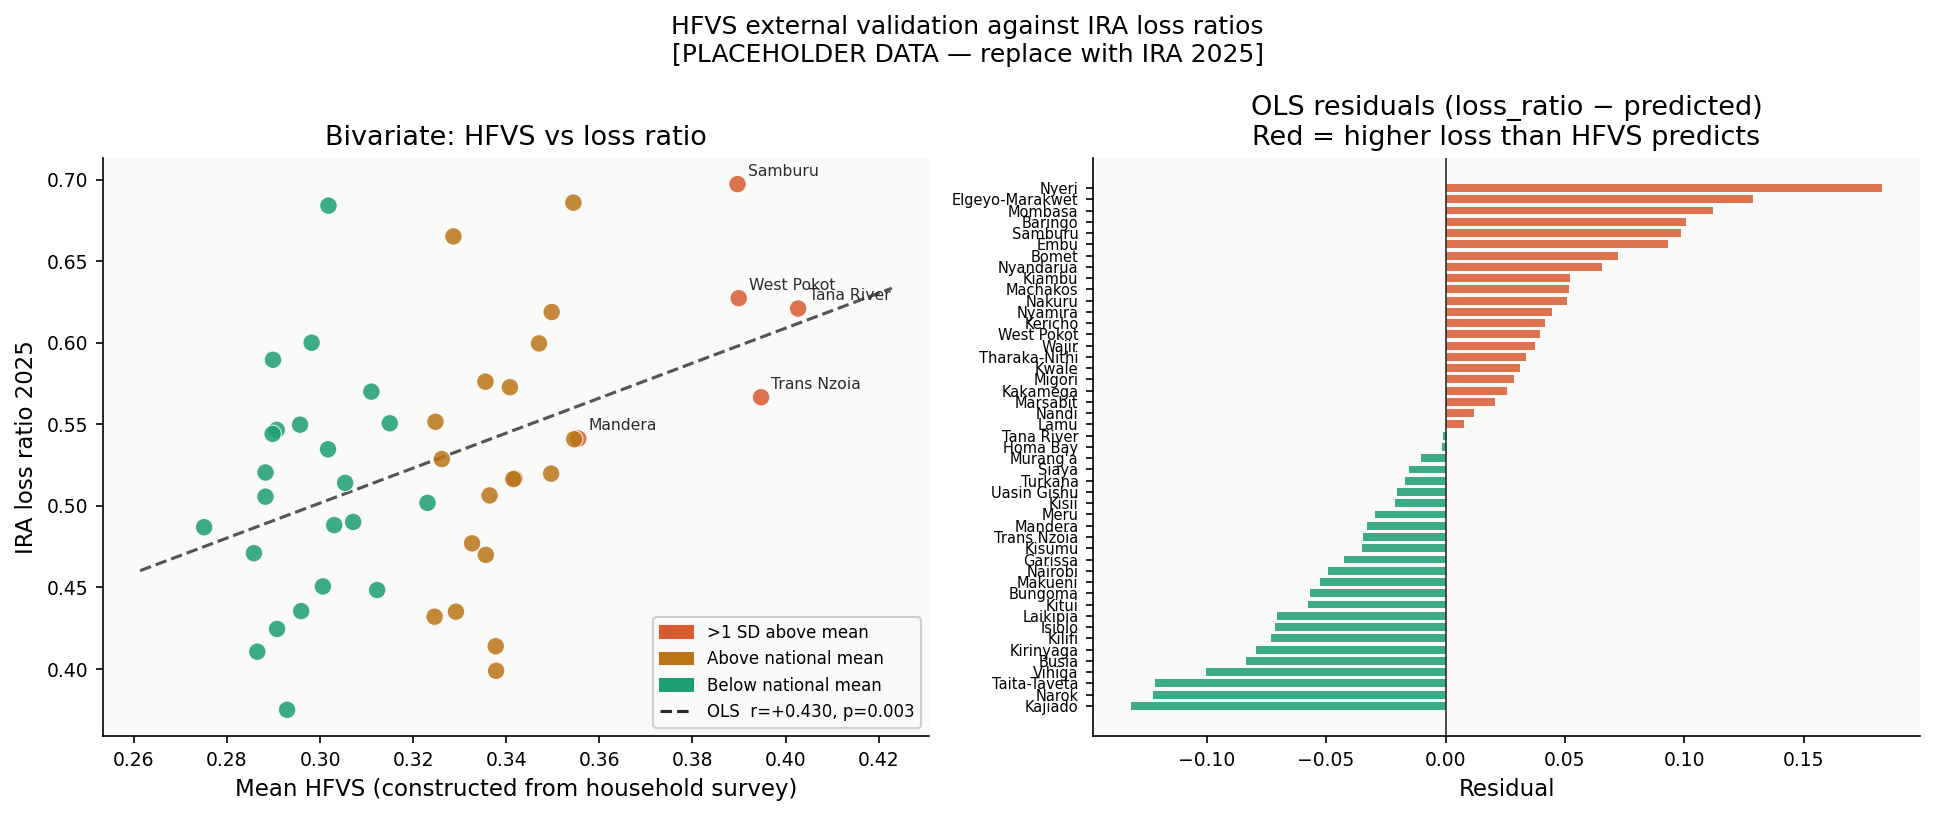

IRA validation plot saved.


In [73]:
# ── 7.3 Validation scatter plot (publication quality) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle(
    f'HFVS external validation against IRA loss ratios\n'
    f'{"[PLACEHOLDER DATA — replace with IRA 2025]" if USING_PLACEHOLDER else "IRA Annual Report 2025"}',
    fontsize=12, fontweight='500'
)

# Panel A: Raw scatter with regression line
ax = axes[0]
scatter_colors = [
    RED if v > national_mean_hfvs + national_std else
    AMBER if v > national_mean_hfvs else
    TEAL
    for v in validation_df['mean_hfvs']
]
ax.scatter(
    validation_df['mean_hfvs'], validation_df['loss_ratio'],
    c=scatter_colors, s=70, alpha=0.85, edgecolors='white', linewidth=0.5, zorder=3
)

# Regression line
x_range = np.linspace(validation_df['mean_hfvs'].min() * 0.95,
                       validation_df['mean_hfvs'].max() * 1.05, 100)
m_simple = np.polyfit(validation_df['mean_hfvs'], validation_df['loss_ratio'], 1)
ax.plot(x_range, np.polyval(m_simple, x_range),
        color=DARK, linewidth=1.5, linestyle='--', alpha=0.8,
        label=f'OLS fit  r={r_pearson:+.3f}, p={p_pearson:.3f}')

# Label top 5 counties
top5_names = county_risk.head(5)['county_name'].tolist()
for _, row in validation_df.iterrows():
    if row['county_name'] in top5_names:
        ax.annotate(
            row['county_name'],
            xy=(row['mean_hfvs'], row['loss_ratio']),
            xytext=(5, 4), textcoords='offset points',
            fontsize=7.5, color=DARK,
        )

ax.set_xlabel('Mean HFVS (constructed from household survey)', fontsize=11)
ax.set_ylabel('IRA loss ratio 2025', fontsize=11)
ax.set_title('Bivariate: HFVS vs loss ratio')
ax.legend(fontsize=9)

legend_elements = [
    mpatches.Patch(color=RED,   label='>1 SD above mean'),
    mpatches.Patch(color=AMBER, label='Above national mean'),
    mpatches.Patch(color=TEAL,  label='Below national mean'),
]
ax.legend(handles=legend_elements + [
    plt.Line2D([0],[0], color=DARK, linestyle='--',
               label=f'OLS  r={r_pearson:+.3f}, p={p_pearson:.3f}')
], fontsize=8)

# Panel B: Residual analysis — where does HFVS over/under-predict loss?
ax2 = axes[1]
validation_df['ols_pred']   = m3.predict(reg_df_s)
validation_df['ols_resid']  = validation_df['loss_ratio'] - validation_df['ols_pred']
resid_sorted = validation_df.sort_values('ols_resid')

resid_colors = [RED if r > 0 else TEAL for r in resid_sorted['ols_resid']]
ax2.barh(
    resid_sorted['county_name'], resid_sorted['ols_resid'],
    color=resid_colors, alpha=0.85, edgecolor='none', height=0.7
)
ax2.axvline(0, color=DARK, linewidth=0.8)
ax2.set_title('OLS residuals (loss_ratio − predicted)\nRed = higher loss than HFVS predicts')
ax2.set_xlabel('Residual')
ax2.tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.savefig(FIGS / '05e_ira_validation.png', dpi=180, bbox_inches='tight')
plt.show()
print("IRA validation plot saved.")

---
## 8. Spatial Residual Analysis — Model Performance by County

Where does XGBoost (Track A) fail spatially?
Counties with large residuals may have structural vulnerability drivers
not captured in household-level features — a substantive Chapter 4 discussion point.

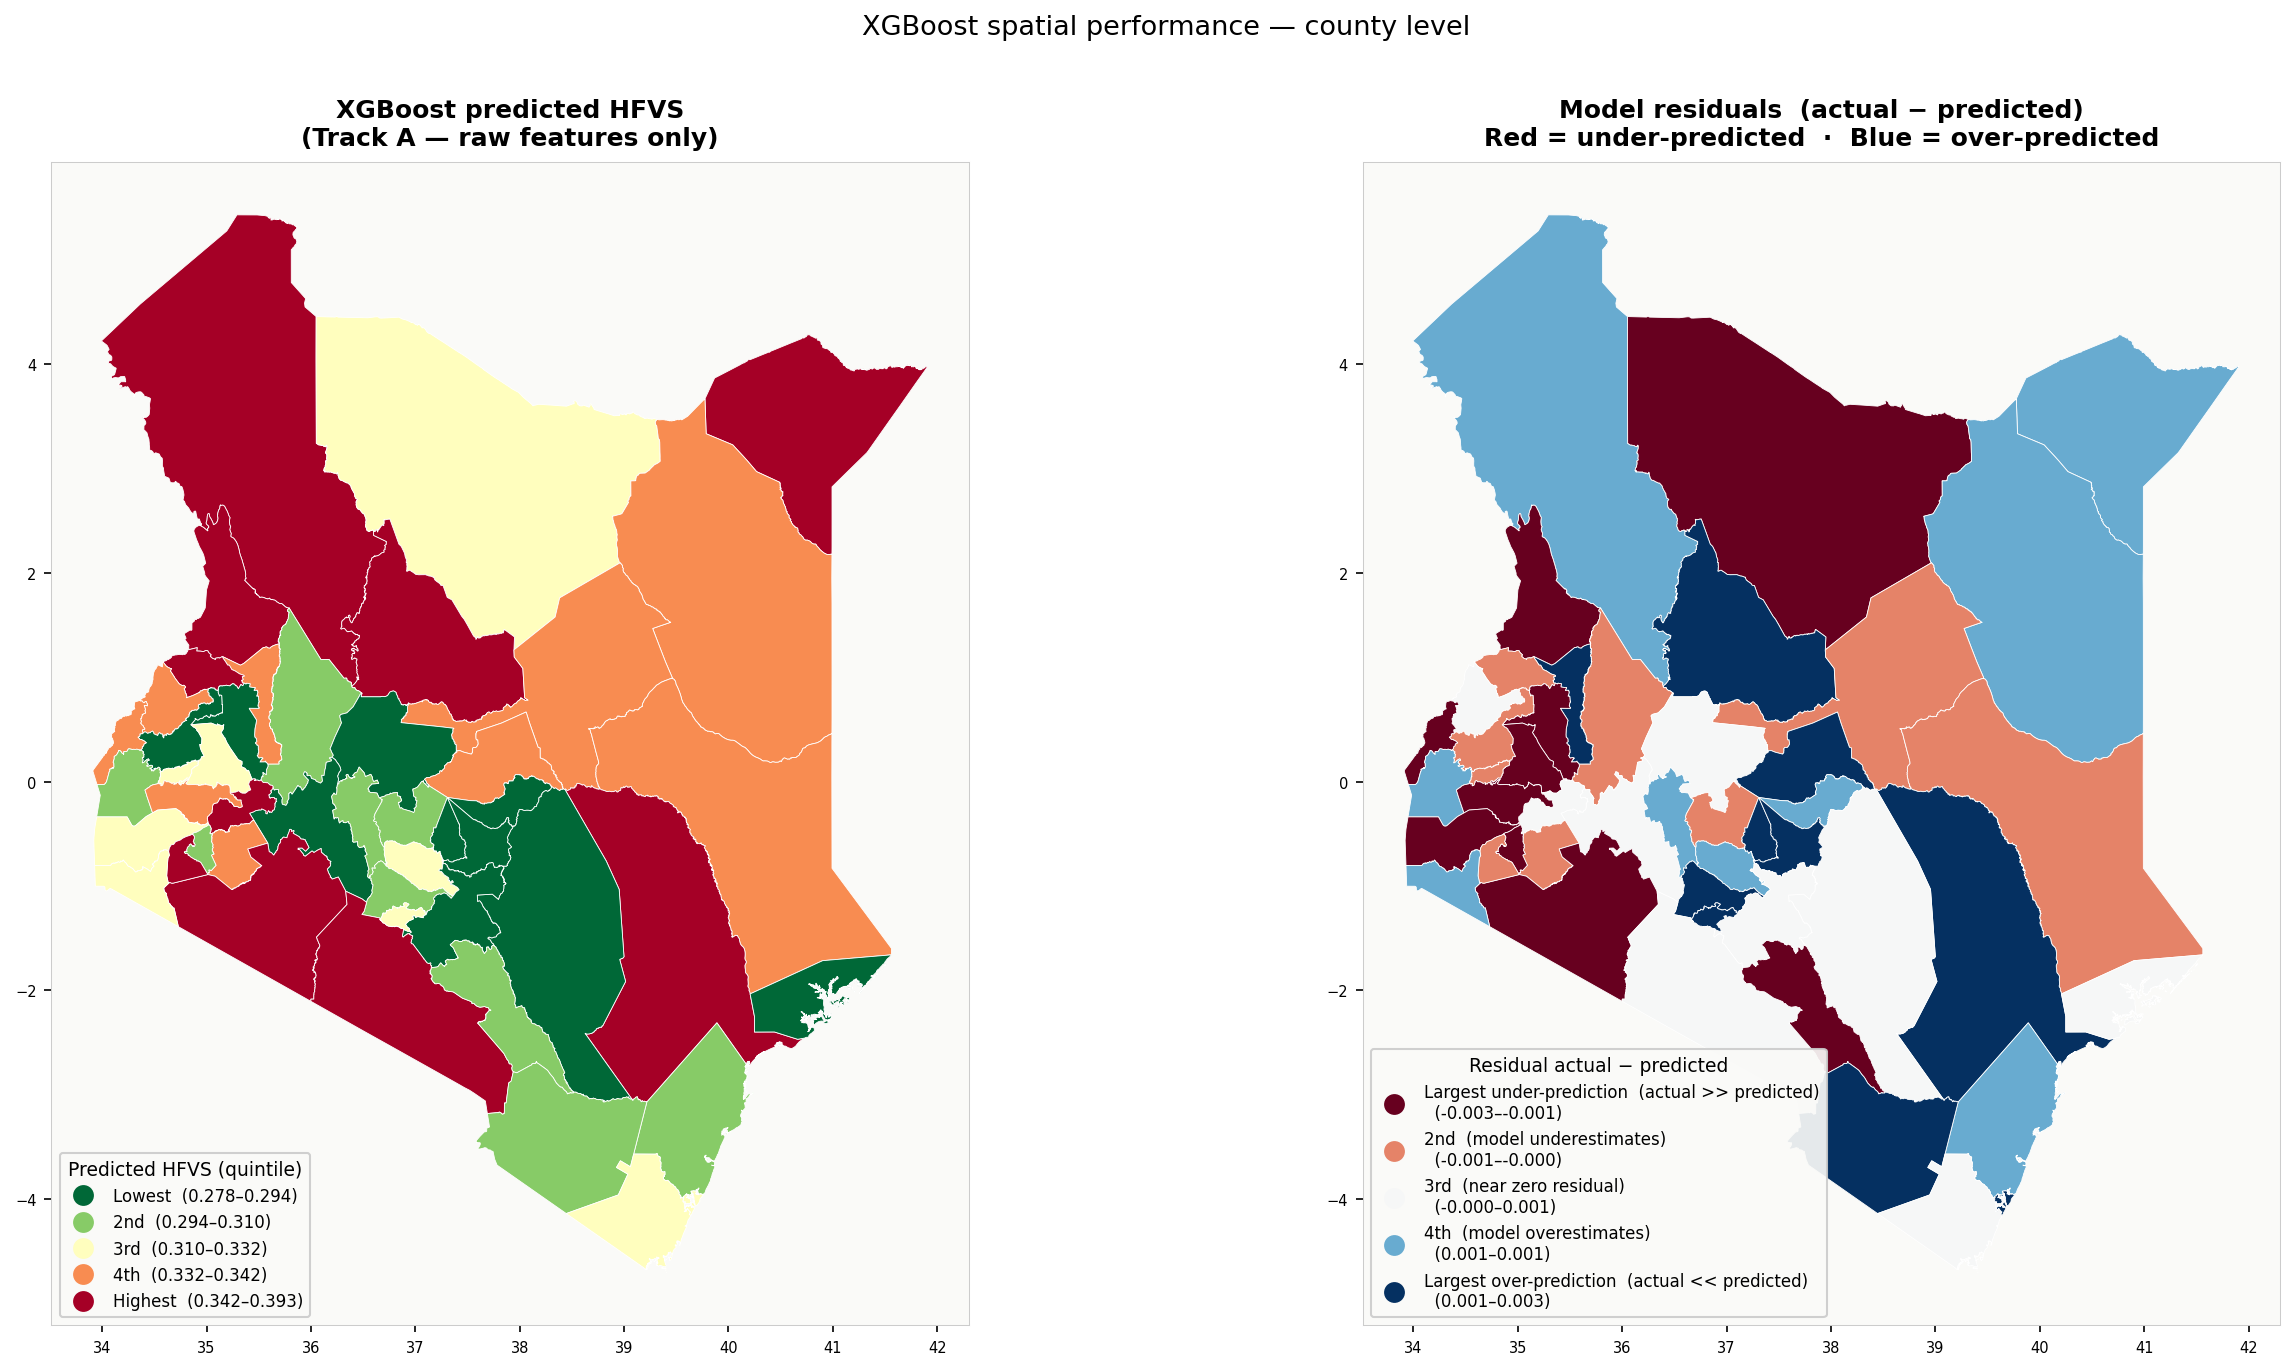

Spatial residuals map saved.


In [87]:
# ── 8.1 County residual map ────────────────────────────────────────────
kenya_resid = kenya_gdf.merge(
    county_risk[['county_name', 'residual_xgb', 'abs_residual_xgb',
                 'mean_hfvs', 'mean_pred_xgb']],
    left_on='county_name_std', right_on='county_name', how='left'
)

quintile_labels = ['Lowest', '2nd', '3rd', '4th', 'Highest']

def quintile_legend_labels(series, fmt='{:.3f}'):
    """Generate 'Quintile (lo–hi)' labels from a series."""
    clean = series.dropna()

    # ✅ FIX: extract valid f-string format spec ('.3f' instead of ':.3f')
    fmt_spec = fmt[2:-1]

    return [
        f'{q}  ({clean.quantile(i*0.2):{fmt_spec}}–{clean.quantile((i+1)*0.2):{fmt_spec}})'
        for i, q in enumerate(quintile_labels)
    ]

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# ── Panel A: Predicted HFVS ───────────────────────────────────────────
kenya_resid.plot(
    column       = 'mean_pred_xgb',
    cmap         = 'RdYlGn_r',
    scheme       = 'quantiles',
    k            = 5,
    linewidth    = 0.4,
    edgecolor    = 'white',
    legend       = True,
    legend_kwds  = {
        'title'          : 'Predicted HFVS (quintile)',
        'title_fontsize' : 9,
        'fontsize'       : 8,
        'fmt'            : '{:.3f}',
        'loc'            : 'lower left',
        'framealpha'     : 0.92,
        'labels'         : quintile_legend_labels(kenya_resid['mean_pred_xgb']),
    },
    ax           = axes[0],
    missing_kwds = {'color': '#DDDDDD', 'label': 'No data'},
)
axes[0].set_title('XGBoost predicted HFVS\n(Track A — raw features only)',
                  fontsize=12, fontweight='600', pad=8)
axes[0].set_aspect('equal')

# ── Panel B: Residuals (diverging) ────────────────────────────────────
resid_labels = [
    'Largest under-prediction  (actual >> predicted)',
    '2nd  (model underestimates)',
    '3rd  (near zero residual)',
    '4th  (model overestimates)',
    'Largest over-prediction  (actual << predicted)',
]

clean_resid = kenya_resid["residual_xgb"].dropna()

kenya_resid.plot(
    column       = 'residual_xgb',
    cmap         = 'RdBu',
    scheme       = 'quantiles',
    k            = 5,
    linewidth    = 0.4,
    edgecolor    = 'white',
    legend       = True,
    legend_kwds  = {
        'title'          : 'Residual actual − predicted',
        'title_fontsize' : 9,
        'fontsize'       : 8,
        'fmt'            : '{:.3f}',
        'loc'            : 'lower left',
        'framealpha'     : 0.92,
        'labels'         : [
            f'{lbl}\n  ({clean_resid.quantile(i*0.2):.3f}–'
            f'{clean_resid.quantile((i+1)*0.2):.3f})'
            for i, lbl in enumerate(resid_labels)
        ],
    },
    ax           = axes[1],
    missing_kwds = {'color': '#DDDDDD', 'label': 'No data'},
)
axes[1].set_title('Model residuals  (actual − predicted)\n'
                  'Red = under-predicted  ·  Blue = over-predicted',
                  fontsize=12, fontweight='600', pad=8)
axes[1].set_aspect('equal')

# Thin border on both panels
for ax in axes:
    ax.tick_params(labelsize=7)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color('#CCCCCC')

fig.suptitle('XGBoost spatial performance — county level',
             fontsize=13, fontweight='500', y=1.01)
plt.tight_layout(w_pad=3)
plt.savefig(FIGS / '05f_spatial_residuals_map.png', dpi=180, bbox_inches='tight')
plt.show()
print("Spatial residuals map saved.")

In [75]:
# ── 8.2 Residual analysis table ────────────────────────────────────────
resid_analysis = county_risk[[
    'county_name', 'mean_hfvs', 'mean_pred_xgb',
    'residual_xgb', 'abs_residual_xgb',
    'pct_urban', 'n_households'
]].copy()
resid_analysis['residual_pct'] = (
    resid_analysis['residual_xgb'] / resid_analysis['mean_hfvs'] * 100
).round(1)

print("10 counties where XGBoost most UNDER-predicts (actual > predicted):")
print("  = Structural vulnerability drivers NOT in household features")
print(resid_analysis.sort_values('residual_xgb', ascending=False).head(10)
      .to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print("\n10 counties where XGBoost most OVER-predicts (actual < predicted):")
print("  = Model sees risk signals but households report lower vulnerability")
print(resid_analysis.sort_values('residual_xgb', ascending=True).head(10)
      .to_string(index=False, float_format=lambda x: f'{x:.4f}'))

resid_analysis.to_csv(TABS / 'county_residuals_xgb.csv', index=False)

10 counties where XGBoost most UNDER-predicts (actual > predicted):
  = Structural vulnerability drivers NOT in household features
    county_name  mean_hfvs  mean_pred_xgb  residual_xgb  abs_residual_xgb  pct_urban  n_households  residual_pct
         Kiambu     0.3110         0.3050        0.0033            0.0136     0.4984           319        1.1000
           Meru     0.3415         0.3348        0.0029            0.0140     0.3252           412        0.9000
        Nairobi     0.3231         0.3282        0.0023            0.0136     1.0000          1059        0.7000
Elgeyo-Marakwet     0.3544         0.3373        0.0019            0.0099     0.3223           391        0.5000
        Mombasa     0.3286         0.3268        0.0017            0.0153     1.0000           425        0.5000
      Kirinyaga     0.2865         0.2883        0.0017            0.0105     0.4044           450        0.6000
           Embu     0.2899         0.2830        0.0015            0.0104     

---
## 9. Weighting Strategy Robustness — County Rankings

Confirms that the three HFVS weighting strategies produce consistent county rankings.
This is the Chapter 5 robustness argument: county findings are not an artefact of weight choice.

In [76]:
# ── County means under all 3 weighting strategies ─────────────────────
strat_cols = ['hfvs', 'hfvs_equal', 'hfvs_pca']
strat_available = [c for c in strat_cols if c in master_full.columns]

county_strat = {}
for col in strat_available:
    county_strat[col] = master_full.groupby('county_name')[col].mean()

strat_df = pd.DataFrame(county_strat).dropna()
strat_ranks = strat_df.rank(ascending=False)

print("Spearman rank correlation between weighting strategies:")
labels = {'hfvs': 'Literature (primary)', 'hfvs_equal': 'Equal weights',
          'hfvs_pca': 'PCA-derived'}

concordance_results = []
cols = list(strat_ranks.columns)
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        a, b = cols[i], cols[j]
        rho, pval = stats.spearmanr(strat_ranks[a], strat_ranks[b])
        sig = '✓' if rho > 0.90 else '△'
        print(f"  {labels.get(a, a):<25} vs {labels.get(b, b):<22} ρ = {rho:.4f}  {sig}")
        concordance_results.append({'strategy_a': a, 'strategy_b': b, 'rho': rho, 'p': pval})

print("\nρ > 0.90 = weighting choice does not drive county vulnerability rankings.")

pd.DataFrame(concordance_results).to_csv(TABS / 'weighting_concordance.csv', index=False)

Spearman rank correlation between weighting strategies:
  Literature (primary)      vs Equal weights          ρ = 0.9460  ✓
  Literature (primary)      vs PCA-derived            ρ = 0.7203  △
  Equal weights             vs PCA-derived            ρ = 0.8586  △

ρ > 0.90 = weighting choice does not drive county vulnerability rankings.


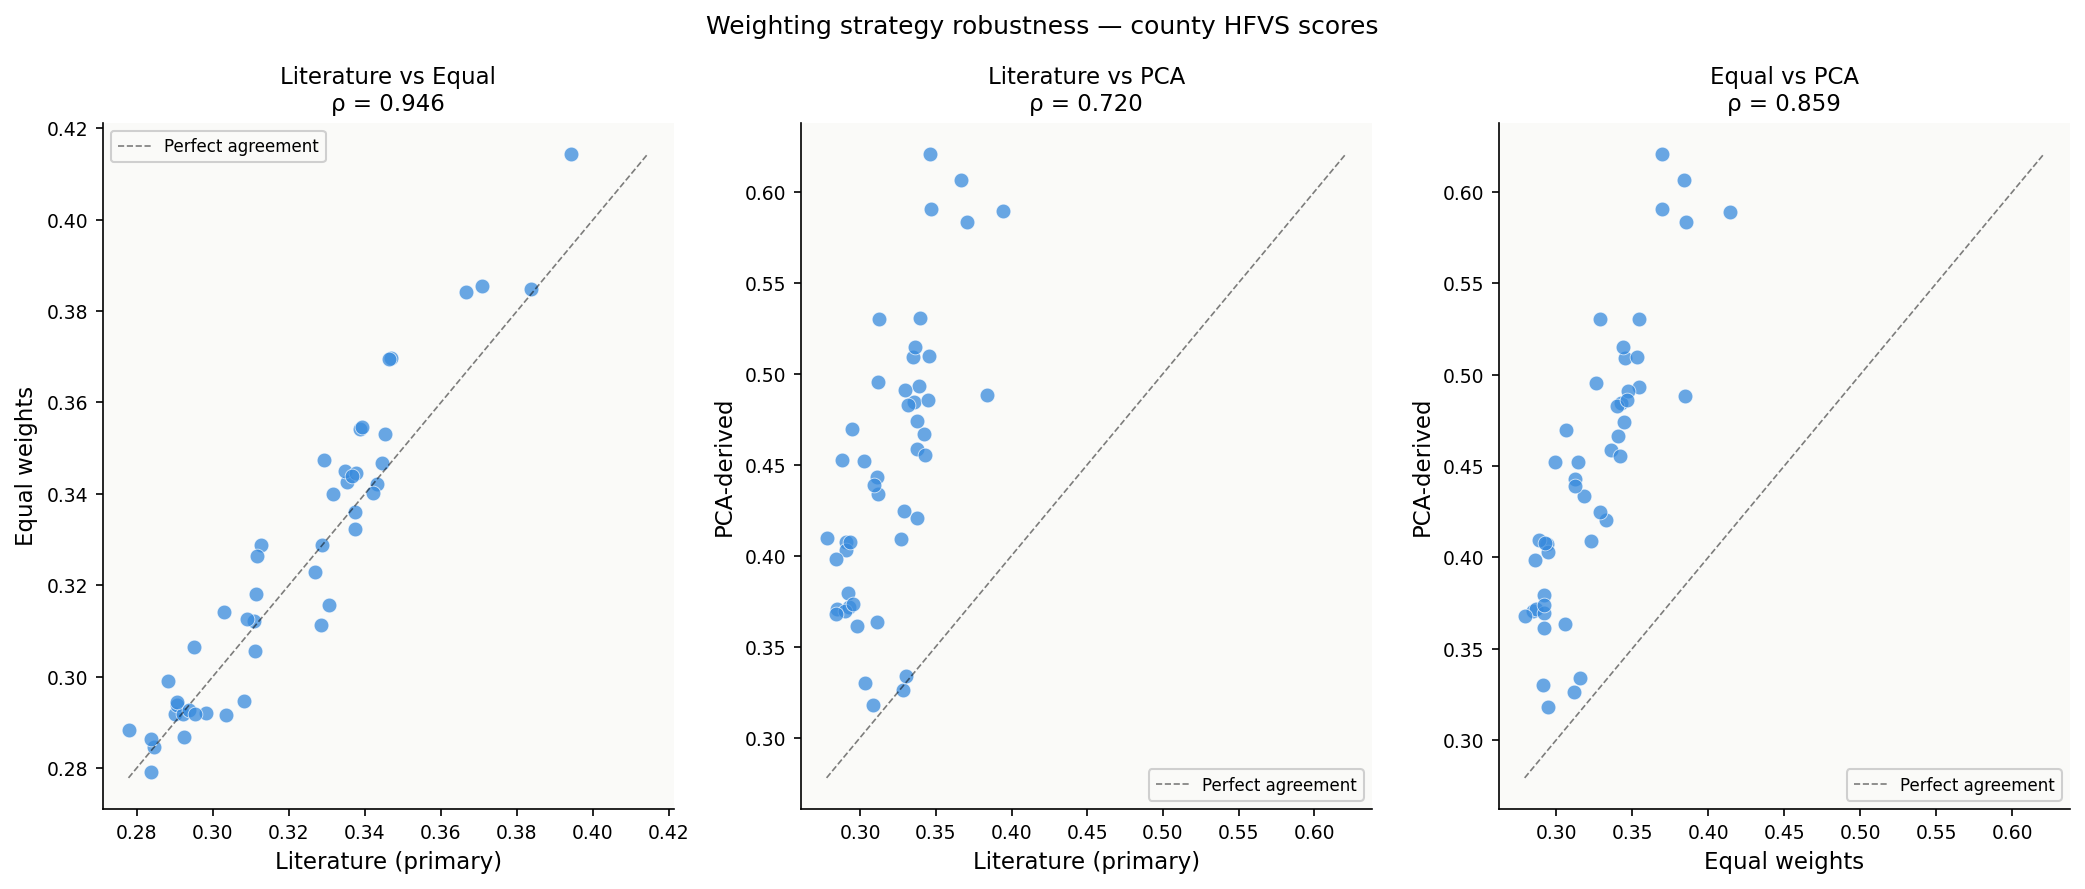

In [77]:
# ── Rank stability visualisation ──────────────────────────────────────
if len(strat_available) >= 2:
    valid_pairs = [p for p in pairs if p[0] in strat_df.columns and p[1] in strat_df.columns]

    fig, axes = plt.subplots(1, max(len(valid_pairs), 1), figsize=(14, 6))
    if not hasattr(axes, '__iter__'): axes = [axes]

    pairs = [
        ('hfvs',       'hfvs_equal', 'Literature vs Equal'),
        ('hfvs',       'hfvs_pca',   'Literature vs PCA'),
        ('hfvs_equal', 'hfvs_pca',   'Equal vs PCA'),
    ]

    valid_pairs = [p for p in pairs if p[0] in strat_df.columns and p[1] in strat_df.columns]

    for ax, (a, b, title) in zip(axes, valid_pairs):
        ax.scatter(strat_df[a], strat_df[b], c=BLUE, s=50, alpha=0.75,
                   edgecolors='white', linewidth=0.4)
        rng = [strat_df[[a, b]].min().min(), strat_df[[a, b]].max().max()]
        ax.plot(rng, rng, 'k--', lw=0.8, alpha=0.5, label='Perfect agreement')
        r, _ = stats.spearmanr(strat_df[a], strat_df[b])
        ax.set_title(f'{title}\nρ = {r:.3f}', fontsize=11)
        ax.set_xlabel(labels.get(a, a))
        ax.set_ylabel(labels.get(b, b))
        ax.legend(fontsize=8)

    plt.suptitle('Weighting strategy robustness — county HFVS scores', fontsize=12)
    plt.tight_layout()
    plt.savefig(FIGS / '05g_weighting_robustness.png', dpi=180, bbox_inches='tight')
    plt.show()

---
## 10. Urban–Rural Disaggregation

HFVS patterns differ structurally between urban and rural households.
This section disaggregates at county level to show within-county inequality.

Urban vs rural HFVS — top 10 counties by rural vulnerability:
                 Rural  Urban    gap
county_name                         
Trans Nzoia      0.411  0.342  0.069
Samburu          0.409  0.315  0.094
Tana River       0.404  0.383  0.021
West Pokot       0.393  0.323  0.070
Wajir            0.373  0.284  0.088
Turkana          0.371  0.314  0.057
Mandera          0.362  0.334  0.029
Kajiado          0.358  0.330  0.028
Elgeyo-Marakwet  0.357  0.302  0.056
Kisii            0.354  0.320  0.034

National: mean Rural HFVS = 0.327
          mean Urban HFVS = 0.312
          Rural–Urban gap = 0.014


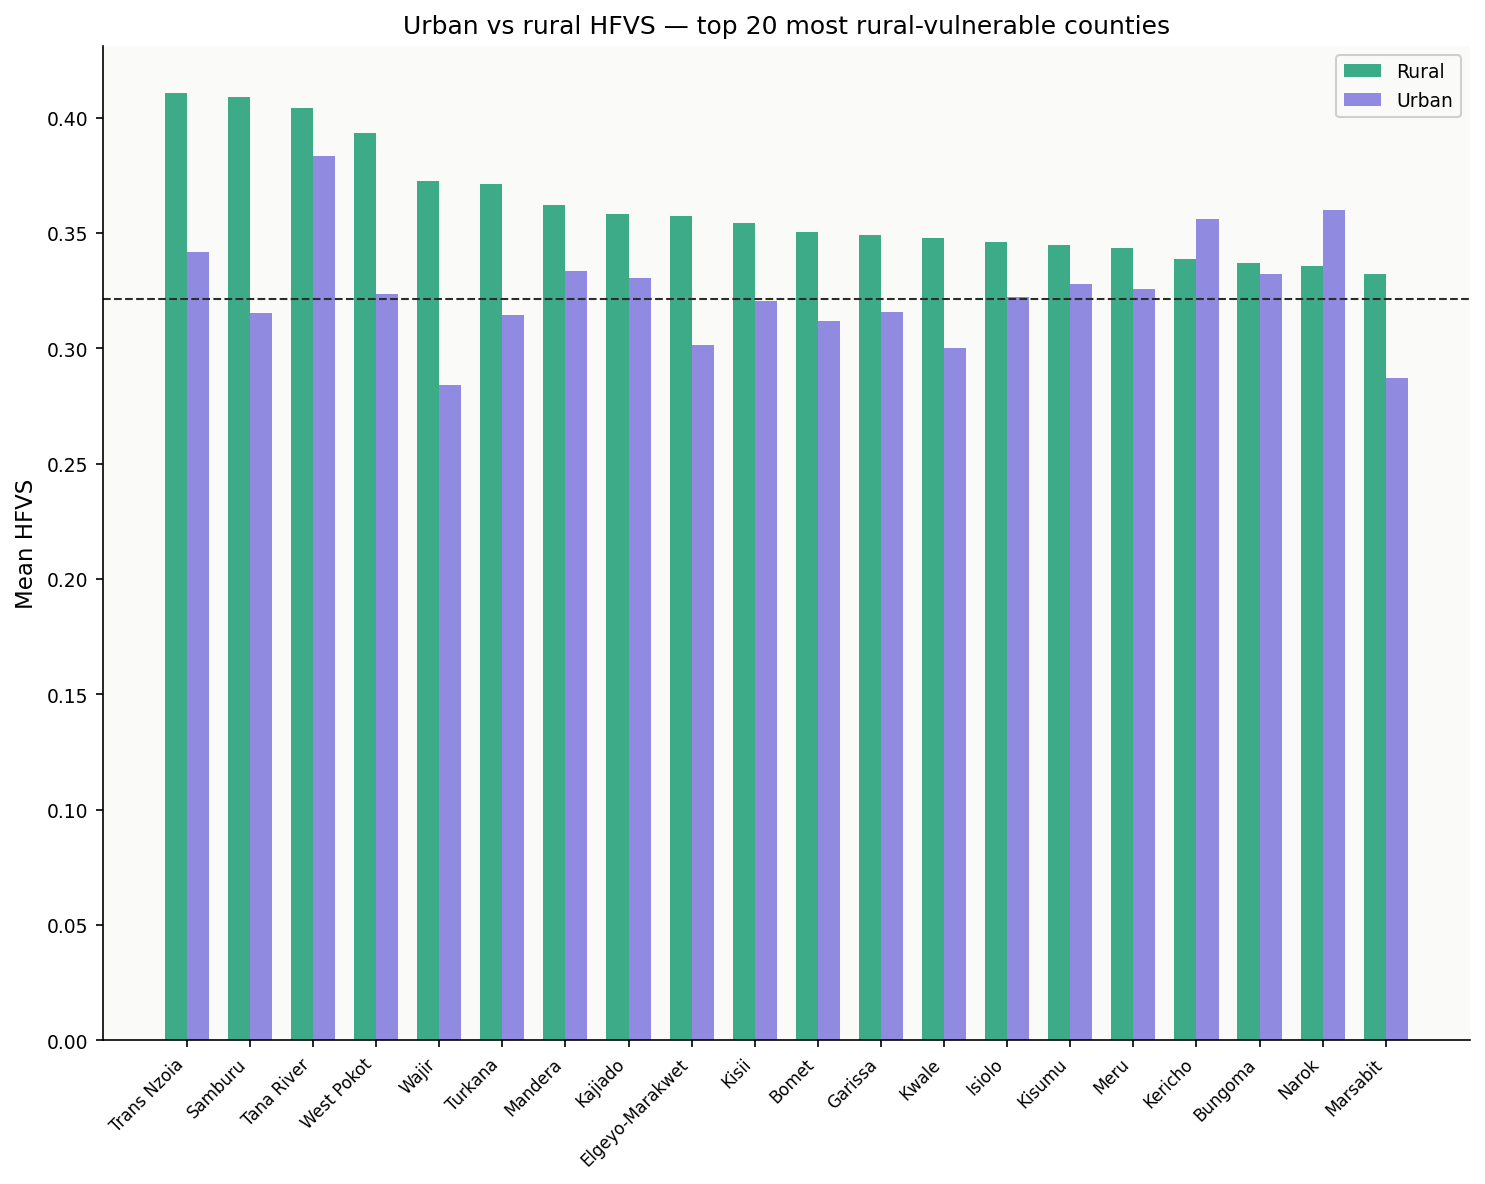

In [78]:
# ── Urban vs rural HFVS by county ─────────────────────────────────────
urban_rural = master_full.groupby(['county_name', 'residence'])['hfvs'].mean().unstack()
urban_rural.columns.name = None
urban_rural = urban_rural.dropna(subset=['Rural']).sort_values('Rural', ascending=False)

# Rural–urban gap
if 'Urban' in urban_rural.columns and 'Rural' in urban_rural.columns:
    urban_rural['gap'] = urban_rural['Rural'] - urban_rural['Urban']
    print("Urban vs rural HFVS — top 10 counties by rural vulnerability:")
    print(urban_rural.head(10).round(3).to_string())
    print(f"\nNational: mean Rural HFVS = {urban_rural['Rural'].mean():.3f}")
    print(f"          mean Urban HFVS = {urban_rural['Urban'].mean():.3f}")
    print(f"          Rural–Urban gap = {urban_rural['gap'].mean():.3f}")

    # Plot
    top20 = urban_rural.head(20)
    fig, ax = plt.subplots(figsize=(10, 8))
    x = np.arange(len(top20))
    w = 0.35
    ax.bar(x - w/2, top20['Rural'],  w, label='Rural',  color=TEAL,   alpha=0.85)
    ax.bar(x + w/2, top20['Urban'],  w, label='Urban',  color=PURPLE, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(top20.index, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Mean HFVS')
    ax.set_title('Urban vs rural HFVS — top 20 most rural-vulnerable counties', fontsize=12)
    ax.legend()
    ax.axhline(master_full['hfvs'].mean(), color=DARK, linestyle='--', lw=1,
               label='National mean')
    plt.tight_layout()
    plt.savefig(FIGS / '05h_urban_rural_hfvs.png', dpi=180, bbox_inches='tight')
    plt.show()

---
## 11. Final Summary — Chapter 5 Key Numbers

In [79]:
# ── Print the Chapter 5 key statistics ────────────────────────────────
top5_c    = county_risk.head(5)
bottom5_c = county_risk.tail(5)
hfvs_spread = county_risk['mean_hfvs'].max() - county_risk['mean_hfvs'].min()

print("═" * 70)
print("CHAPTER 5 — KEY STATISTICS FOR WRITE-UP")
print("═" * 70)
print()
print("── Vulnerability distribution ──────────────────────────────────")
print(f"  National mean HFVS             : {national_mean_hfvs:.4f}")
print(f"  National median HFVS           : {national_median_hfvs:.4f}")
print(f"  Inter-county range             : {hfvs_spread:.4f}")
print(f"  SD (county means)              : {national_std:.4f}")
print(f"  % households high vulnerability: "
      f"{(master_full['target_binary']==1).mean()*100:.1f}%")
print()
print("── Top 5 most vulnerable counties ─────────────────────────────")
for _, r in top5_c.iterrows():
    print(f"  #{int(r['hfvs_rank']):>2} {r['county_name']:<20} HFVS={r['mean_hfvs']:.3f}  "
          f"high_vuln={r['pct_high_vuln']*100:.1f}%  urban={r['pct_urban']*100:.0f}%")
print()
print("── Bottom 5 least vulnerable counties ─────────────────────────")
for _, r in bottom5_c.iterrows():
    print(f"  #{int(r['hfvs_rank']):>2} {r['county_name']:<20} HFVS={r['mean_hfvs']:.3f}  "
          f"high_vuln={r['pct_high_vuln']*100:.1f}%  urban={r['pct_urban']*100:.0f}%")
print()
print("── IRA validation ──────────────────────────────────────────────")
print(f"  {'[PLACEHOLDER — replace with IRA 2025 data]' if USING_PLACEHOLDER else '[LIVE IRA 2025 DATA]'}")
print(f"  Pearson  r = {r_pearson:+.4f}  (p = {p_pearson:.4f})")
print(f"  Spearman ρ = {r_spearman:+.4f}  (p = {p_spearman:.4f})")
print(f"  Full OLS R² (M3 with controls) = {m3.rsquared:.4f}")
print(f"  HFVS coefficient (standardised) = {m3.params.get('mean_hfvs_z',np.nan):.4f}")
print()
print("── Weighting robustness ────────────────────────────────────────")
for res in concordance_results:
    a = labels.get(res['strategy_a'], res['strategy_a'])
    b = labels.get(res['strategy_b'], res['strategy_b'])
    print(f"  {a:<22} vs {b:<20} ρ = {res['rho']:.4f}")
print()
print("═" * 70)

══════════════════════════════════════════════════════════════════════
CHAPTER 5 — KEY STATISTICS FOR WRITE-UP
══════════════════════════════════════════════════════════════════════

── Vulnerability distribution ──────────────────────────────────
  National mean HFVS             : 0.3236
  National median HFVS           : 0.3246
  Inter-county range             : 0.1276
  SD (county means)              : 0.0313
  % households high vulnerability: 40.0%

── Top 5 most vulnerable counties ─────────────────────────────
  # 1 Tana River           HFVS=0.403  high_vuln=74.0%  urban=47%
  # 2 Trans Nzoia          HFVS=0.395  high_vuln=67.6%  urban=39%
  # 3 West Pokot           HFVS=0.390  high_vuln=77.2%  urban=38%
  # 4 Samburu              HFVS=0.390  high_vuln=75.1%  urban=41%
  # 5 Mandera              HFVS=0.355  high_vuln=57.1%  urban=53%

── Bottom 5 least vulnerable counties ─────────────────────────
  #43 Tharaka-Nithi        HFVS=0.288  high_vuln=24.4%  urban=38%
  #44 Kakamega   

In [80]:
# ── Save complete county risk profile ─────────────────────────────────
# Final output: single CSV with everything notebook 05 and the thesis need
final_export = county_risk.merge(
    validation_df[['county_name', 'loss_ratio', 'ols_pred', 'ols_resid']],
    on='county_name', how='left'
)
final_export.to_csv(TABS / 'county_risk_final.csv', index=False)

# Also save as parquet for deployment notebook
pl.from_pandas(final_export).write_parquet(PQ / 'county_risk_final.parquet')

print(f"Final county profile saved: {final_export.shape}")
print(f"  Columns: {list(final_export.columns)}")
print(f"\nFiles written:")
print(f"  {TABS}/county_risk_final.csv")
print(f"  {PQ}/county_risk_final.parquet")
print(f"  {FIGS}/05a_county_hfvs_choropleth.png")
print(f"  {FIGS}/05b_dimension_maps.png")
print(f"  {FIGS}/05c_county_ranking.png")
print(f"  {FIGS}/05d_dimension_heatmap.png")
print(f"  {FIGS}/05e_ira_validation.png")
print(f"  {FIGS}/05f_spatial_residuals_map.png")
print(f"  {FIGS}/05g_weighting_robustness.png")
print(f"  {FIGS}/05h_urban_rural_hfvs.png")
print(f"  {TABS}/ira_correlation_results.csv")
print(f"  {TABS}/ols_validation_summary.txt")
print(f"  {TABS}/county_residuals_xgb.csv")
print(f"  {TABS}/weighting_concordance.csv")
print("\nNotebook 04 complete. Ready for notebook 05 (deployment).")

Final county profile saved: (47, 30)
  Columns: ['county_code', 'county_name', 'n_households', 'total_weight', 'mean_hfvs', 'p25_hfvs', 'p75_hfvs', 'pct_high_vuln', 'mean_d1_financial', 'mean_d2_tenure', 'mean_d3_hazard', 'mean_d4_dwelling', 'mean_d5_utility', 'pct_rent_stressed', 'pct_no_land', 'pct_eviction_threat', 'pct_flood_zone', 'pct_no_electricity', 'pct_solid_fuel', 'pct_unsafe_water', 'pct_urban', 'mean_pred_xgb', 'mean_pred_lgb', 'residual_xgb', 'abs_residual_xgb', 'median_log_expenditure', 'hfvs_rank', 'loss_ratio', 'ols_pred', 'ols_resid']

Files written:
  /content/drive/MyDrive/KHS_Dissertation/outputs/tables/v2/county_risk_final.csv
  /content/drive/MyDrive/KHS_Dissertation/data/parquet/county_risk_final.parquet
  /content/drive/MyDrive/KHS_Dissertation/outputs/figures/v2/05a_county_hfvs_choropleth.png
  /content/drive/MyDrive/KHS_Dissertation/outputs/figures/v2/05b_dimension_maps.png
  /content/drive/MyDrive/KHS_Dissertation/outputs/figures/v2/05c_county_ranking.png
  

---
## 12. Push to GitHub

In [81]:
!git config user.email "gronjerono@gmail.com"
!git config user.name  "VAL-Jerono"
!git add notebooks/04_county_risk_mapping.ipynb
!git add outputs/figures/v2/ outputs/tables/v2/ 2>/dev/null || true
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [82]:
!git commit -m "feat(04): county risk mapping — choropleth, IRA validation, OLS, spatial residuals, weighting robustness"
!git push origin main

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
fatal: could not read Username for 'https://github.com': No such device or address
